# Final Project Notebook

DS 5001 Text as Data | Spring 2025

# Metadata

- Full Name: **William Peritz**
- Userid: **wgp3aq**
- GitHub Repo URL: https://github.com/wperitz/Text_as_Data_Final_Project
- UVA Box URL: https://www.dropbox.com/scl/fo/9ajlglwd0goaw3j19ugp9/AIenrQ5xZT-41H2nsBvUAig?rlkey=o6rcn79ih7cykske9bmnxkjg2&st=rb21z3jy&dl=0

# Overview

The goal of the final project is for you to create a **digital analytical edition** of a corpus using the tools, practices, and perspectives you’ve learning in this course. You will select a corpus that has already been digitized and transcribed, parse that into an F-compliant set of tables, and then generate and visualize the results of a series of fitted models. You will also draw some tentative conclusions regarding the linguistic, cultural, psychological, or historical features represented by your corpus. The point of the exercise is to have you work with a corpus through the entire pipeline from ingestion to interpretation. 

Specifically, you will acquire a collection of long-form texts and perform the following operations:

- **Convert** the collection from their source formats (F0) into a set of tables that conform to the Standard Text Analytic Data Model (F2).
- **Annotate** these tables with statistical and linguistic features using NLP libraries such as NLTK (F3).
- **Produce** a vector representation of the corpus to generate TFIDF values to add to the TOKEN (aka CORPUS) and VOCAB tables (F4).
- **Model** the annotated and vectorized model with tables and features derived from the application of unsupervised methods, including PCA, LDA, and word2vec (F5).
- **Explore** your results using statistical and visual methods.
- **Present** conclusions about patterns observed in the corpus by means of these operations.

When you are finished, you will make the results of your work available in GitHub (for code) and UVA Box (for data). You will submit to Gradescope (via Canvas) a PDF version of a Jupyter notebook that contains the information listed below.

# Some Details

- Please fill out your answers in each task below by editing the markdown cell. 
- Replace text that asks you to insert something with the thing, i.e. replace `(INSERT IMAGE HERE)` with an image element, e.g. `![](image.png)`.
- For URLs, just paste the raw URL directly into the text area. Don't worry about providing link labels using `[label](link)`.
- Please do not alter the structure of the document or cell, i.e. the bulleted lists. 
- You may add explanatory paragraphs below the bulleted lists.
- Please name your tables as they are named in each task below.
- Tasks are indicated by headers with point values in parentheses.

# Raw Data

## Source Description (1)

Provide a brief description of your source material, including its provenance and content. Tell us where you found it and what kind of content it contains.

**Source material is a collection of English translations of works written by Fyodor Dostoevsky, a Russian author who lived in the 1800s and remains one of the most influential in Russian history and world literature. Texts were downloaded from Project Gutenberg, an online library of over 75,000 free ebooks with a mission to digitize and archive cultural works (Project gutenberg, Wikipedia). The seletion used in this project contains 4 novels and 2 novellas from Dostoevsky, including classics such as *Crime and Punishment,* *The Brothers Karamazov,* and others. All selected works were written between 1864-1880.**

## Source Features (1)

Add values for the following items. (Do this for all following bulleted lists.)

- Source URL: https://www.gutenberg.org/ebooks/author/314
- UVA Box URL: https://www.dropbox.com/scl/fo/yaygh5jxdz162ewnczttf/AI7DWp5znJIm-jJ761CZe6I?rlkey=34zj9zy19xgd98asg9prlzlb3&st=5v77mq06&dl=0
- Number of raw documents: **6**
- Total size of raw documents (e.g. in MB): **6.47**
- File format(s), e.g. XML, plaintext, etc.: **Plaintext (.txt)**

## Source Document Structure (1)

Provide a brief description of the internal structure of each document. That, describe the typical elements found in document and their relation to each other. For example, a corpus of letters might be described as having a date, an addressee, a salutation, a set of content paragraphs, and closing. If they are various structures, state that.

**These documents are from Project Gutenberg, so their structure resembles the structure of the works we have seen throughout this course. Each document starts with an informational snippet about Project Gutenberg and the copyright permissions associated with the document. It then provides metadata about the original work and the Gutenberg version, often including: Title, Author, Translator, Release Date, Language, Credits.**

**It then begins the actual work, including a table of contents and then the novel's text. One difference is that *Crime and Punishment* does not contain a table of contents. The tables of contents will be removed in the versions used for this project to facilitate regex searching for the start/end points of each chapter.**

**For the text itself, the novels are broken into parts, where each part is broken into chapters. This was Dostoevsky's style. One slight deviation from this structure is the *The Brothers Karamazov,* which is divided into Parts, then Books, then Chapters. In this case, "books" are the same as "parts" in the other texts. Another deviation is that *The Gambler* does not have Parts; it has Chapters as the highest OHCO level. In this project, Chapters will represent the highest OHCO level for all documents.**

**The chapters are broken into standard-style paragraphs, which are broken into sentences and contain both dialogue and narrative words. Also of note, *Crime and Punishment* contains a Translator's Preface that will be removed before processing the data.**

# Parsed and Annotated Data

Parse the raw data into the three core tables of your addition: the `LIB`, `CORPUS`, and `VOCAB` tables.

These tables will be stored as CSV files with header rows.

You may consider using `|` as a delimitter.

Provide the following information for each.

## LIB (2)

The source documents the corpus comprises. These may be books, plays, newspaper articles, abstracts, blog posts, etc. 

Note that these are *not* documents in the sense used to describe a bag-of-words representation of a text, e.g. chapter.

- UVA Box URL: https://www.dropbox.com/scl/fi/vzlzdqtneodagix78z7np/dostoevsky-LIB.csv?rlkey=va7mxben6ovfdwpxinjfs8965&st=jm30r10f&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Parsed_Annotated_Data_Derived_Tables.ipynb
- Delimitter: **Comma**
- Number of observations: **6**
- List of features, including at least three that may be used for model summarization (e.g. date, author, etc.): **date, type (novel or novella), translator**
- Average length of each document in characters:
    - NOTES FROM THE UNDERGROUND: 43981 characters, 21 chapters
    - THE GAMBLER: 60502 characters, 17 chapters
    - CRIME AND PUNISHMENT: 204177 characters, 40 chapters
    - THE IDIOT: 242278 characters, 50 chapters
    - THE POSSESSED: 255013 characters, 23 chapters
    - THE BROTHERS KARAMAZOV: 349220 characters, 96 chapters.
    - **Average Document Length in characters: 192528.5**


## CORPUS (2)

The sequence of word tokens in the corpus, indexed by their location in the corpus and document structures.

- UVA Box URL: https://www.dropbox.com/scl/fi/cdodkmk3qsu63tgkzzd45/dostoevsky-CORPUS.csv?rlkey=upqyx2q516rzsukz06x9m4j46&st=ikl0oa5s&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Parsed_Annotated_Data_Derived_Tables.ipynb
- Delimitter: **comma**
- Number of observations Between (should be >= 500,000 and <= 2,000,000 observations.): **155871**
- OHCO Structure (as delimitted column names): **['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']**
- Columns (as delimitted column names, including `token_str`, `term_str`, `pos`, and `pos_group`): **['pos_tuple', 'pos', 'token_str', 'term_str', 'pos_group']**

## VOCAB (2)

The unique word types (terms) in the corpus.

- UVA Box URL: https://www.dropbox.com/scl/fi/gj0z0al1e0k10r050favw/dostoevsky-VOCAB.csv?rlkey=bak3w7r43pg2lvqd6w8jquxyw&st=xov3gt0i&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Parsed_Annotated_Data_Derived_Tables.ipynb
- Delimitter: **comma**
- Number of observations: **24867**
- Columns (as delimitted names, including `n`, `p`', `i`, `dfidf`, `porter_stem`, `max_pos` and `max_pos_group`, `stop`): **['n', 'n_chars', 'p', 'i', 'max_pos', 'max_pos_group', 'stop', 'porter_stem', 'dfidf']**
- Note: Your VOCAB may contain ngrams. If so, add a feature for `ngram_length`.
- List the top 20 significant words in the corpus by DFIDF.


**['frightened', 'forget', 'absolutely', 'further', 'grew', 'curiosity', 'die', 'directly', 'giving', 'shame', 'seven', 'black', 'mr', 'third', 'impression', 'convinced', 'yours', 'couldnt', 'ground', 'asking']**

# Derived Tables

## BOW (3)

A bag-of-words representation of the CORPUS.

- UVA Box URL: https://www.dropbox.com/scl/fi/jdfcu77ae7sik8mf6zj18/dostoevsky-BOW.csv?rlkey=t052jbhfsodbv5081lfs9llsv&st=9o8fjvq1&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Parsed_Annotated_Data_Derived_Tables.ipynb
- Delimitter: **comma**
- Bag (expressed in terms of OHCO levels): **book_id, chap_id**
- Number of observations: **276464**
- Columns (as delimitted names, including `n`, `tfidf`): **['n', 'tfidf', 'dfidf']**

## DTM (3)

A represenation of the BOW as a sparse count matrix.

- UVA Box URL: https://www.dropbox.com/scl/fi/hfornufy0lgzfwcktbjbi/dostoevsky-DTM.csv?rlkey=z3uh6opgmpyy2hse12o12wdlq&st=dozq8wu4&dl=0
- UVA Box URL of BOW used to generate (if applicable): **N/A**
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Parsed_Annotated_Data_Derived_Tables.ipynb
- Delimitter: **Comma**
- Bag (expressed in terms of OHCO levels): **book_id, chap_id**

## TFIDF (3)

A Document-Term matrix with TFIDF values.

- UVA Box URL: https://www.dropbox.com/scl/fi/7m6ql6k5zpjdklrgihcio/dostoevsky-TFIDF.csv?rlkey=kfn280fr7qnttty3pk7u093el&st=t9c6tajm&dl=0
- UVA Box URL of DTM or BOW used to create: https://www.dropbox.com/scl/fi/hfornufy0lgzfwcktbjbi/dostoevsky-DTM.csv?rlkey=z3uh6opgmpyy2hse12o12wdlq&st=dozq8wu4&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Parsed_Annotated_Data_Derived_Tables.ipynb
- Delimitter: **comma**
- Description of TFIDIF formula ($\LaTeX$ OK):

**I used the 'max' version of the formula:**

TFIDF = [(DTCM.T / DTCM.T.max()).T] * [np.log2(N / DF)]

**where:**

**DTCM = BOW.n.unstack(fill_value=0)**

**N = DTCM.shape[0]**

**DF = DTCM.astype('bool').sum()**

## Reduced and Normalized TFIDF_L2 (3)

A Document-Term matrix with L2 normalized TFIDF values.

- UVA Box URL: https://www.dropbox.com/scl/fi/o5gio3tvttqwk7d4m1p76/dostoevsky-TFIDF_L2.csv?rlkey=owuxboi04g79kfewzkpt4763t&st=wu2lpci0&dl=0
- UVA Box URL of source TFIDF table: https://www.dropbox.com/scl/fi/7m6ql6k5zpjdklrgihcio/dostoevsky-TFIDF.csv?rlkey=kfn280fr7qnttty3pk7u093el&st=t9c6tajm&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Parsed_Annotated_Data_Derived_Tables.ipynb
- Delimitter: **comma**
- Number of features (i.e. significant words): **1000**
- Principle of significant word selection: **DFIDF significance (it is a TFIDF table with top 1000 significant terms, with DFIDF as sig measurement)**

# Models

## PCA Components (4)

- UVA Box URL: https://www.dropbox.com/scl/fi/uch3dton9vb6ma6hxdraa/dostoevsky-PCA_Components.csv?rlkey=pqyfw4qn6p6n10b3v19zia70i&st=pdyyov5f&dl=0
- UVA Box URL of the source TFIDF_L2 table: https://www.dropbox.com/scl/fi/jgld560izfmggjen5kihz/dostoevsky-TFIDF_L2_PCA.csv?rlkey=y9dwnnkmlg7g1uzwu5bzb7y00&st=fna0gmog&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**
- Number of components: **10**
- Library used to generate: **SciPy**
- Top 5 positive terms for first component: **finding failed flashing happens longed**
- Top 5 negative terms for second component: **hes murder murdered killed captain**

## PCA DCM (4)

The document-component matrix generated.

- UVA Box URL: https://www.dropbox.com/scl/fi/auc7rnz6hz5idq3u35l8o/dostoevsky-PCA_DCM.csv?rlkey=q98zu3j0equz4xqu5uu2sngtu&st=uestkxh6&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**

## PCA Loadings (4)

The component-term matrix generated.

- UVA Box URL: https://www.dropbox.com/scl/fi/bam8ap9flyqccqkmsut7u/dostoevsky-PCA_Loadings.csv?rlkey=01hmozno31xi97vnj4o14y9r7&st=fx3w42g9&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**

## PCA Visualization 1 (4)

Include a scatterplot of documents in the space created by the first two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

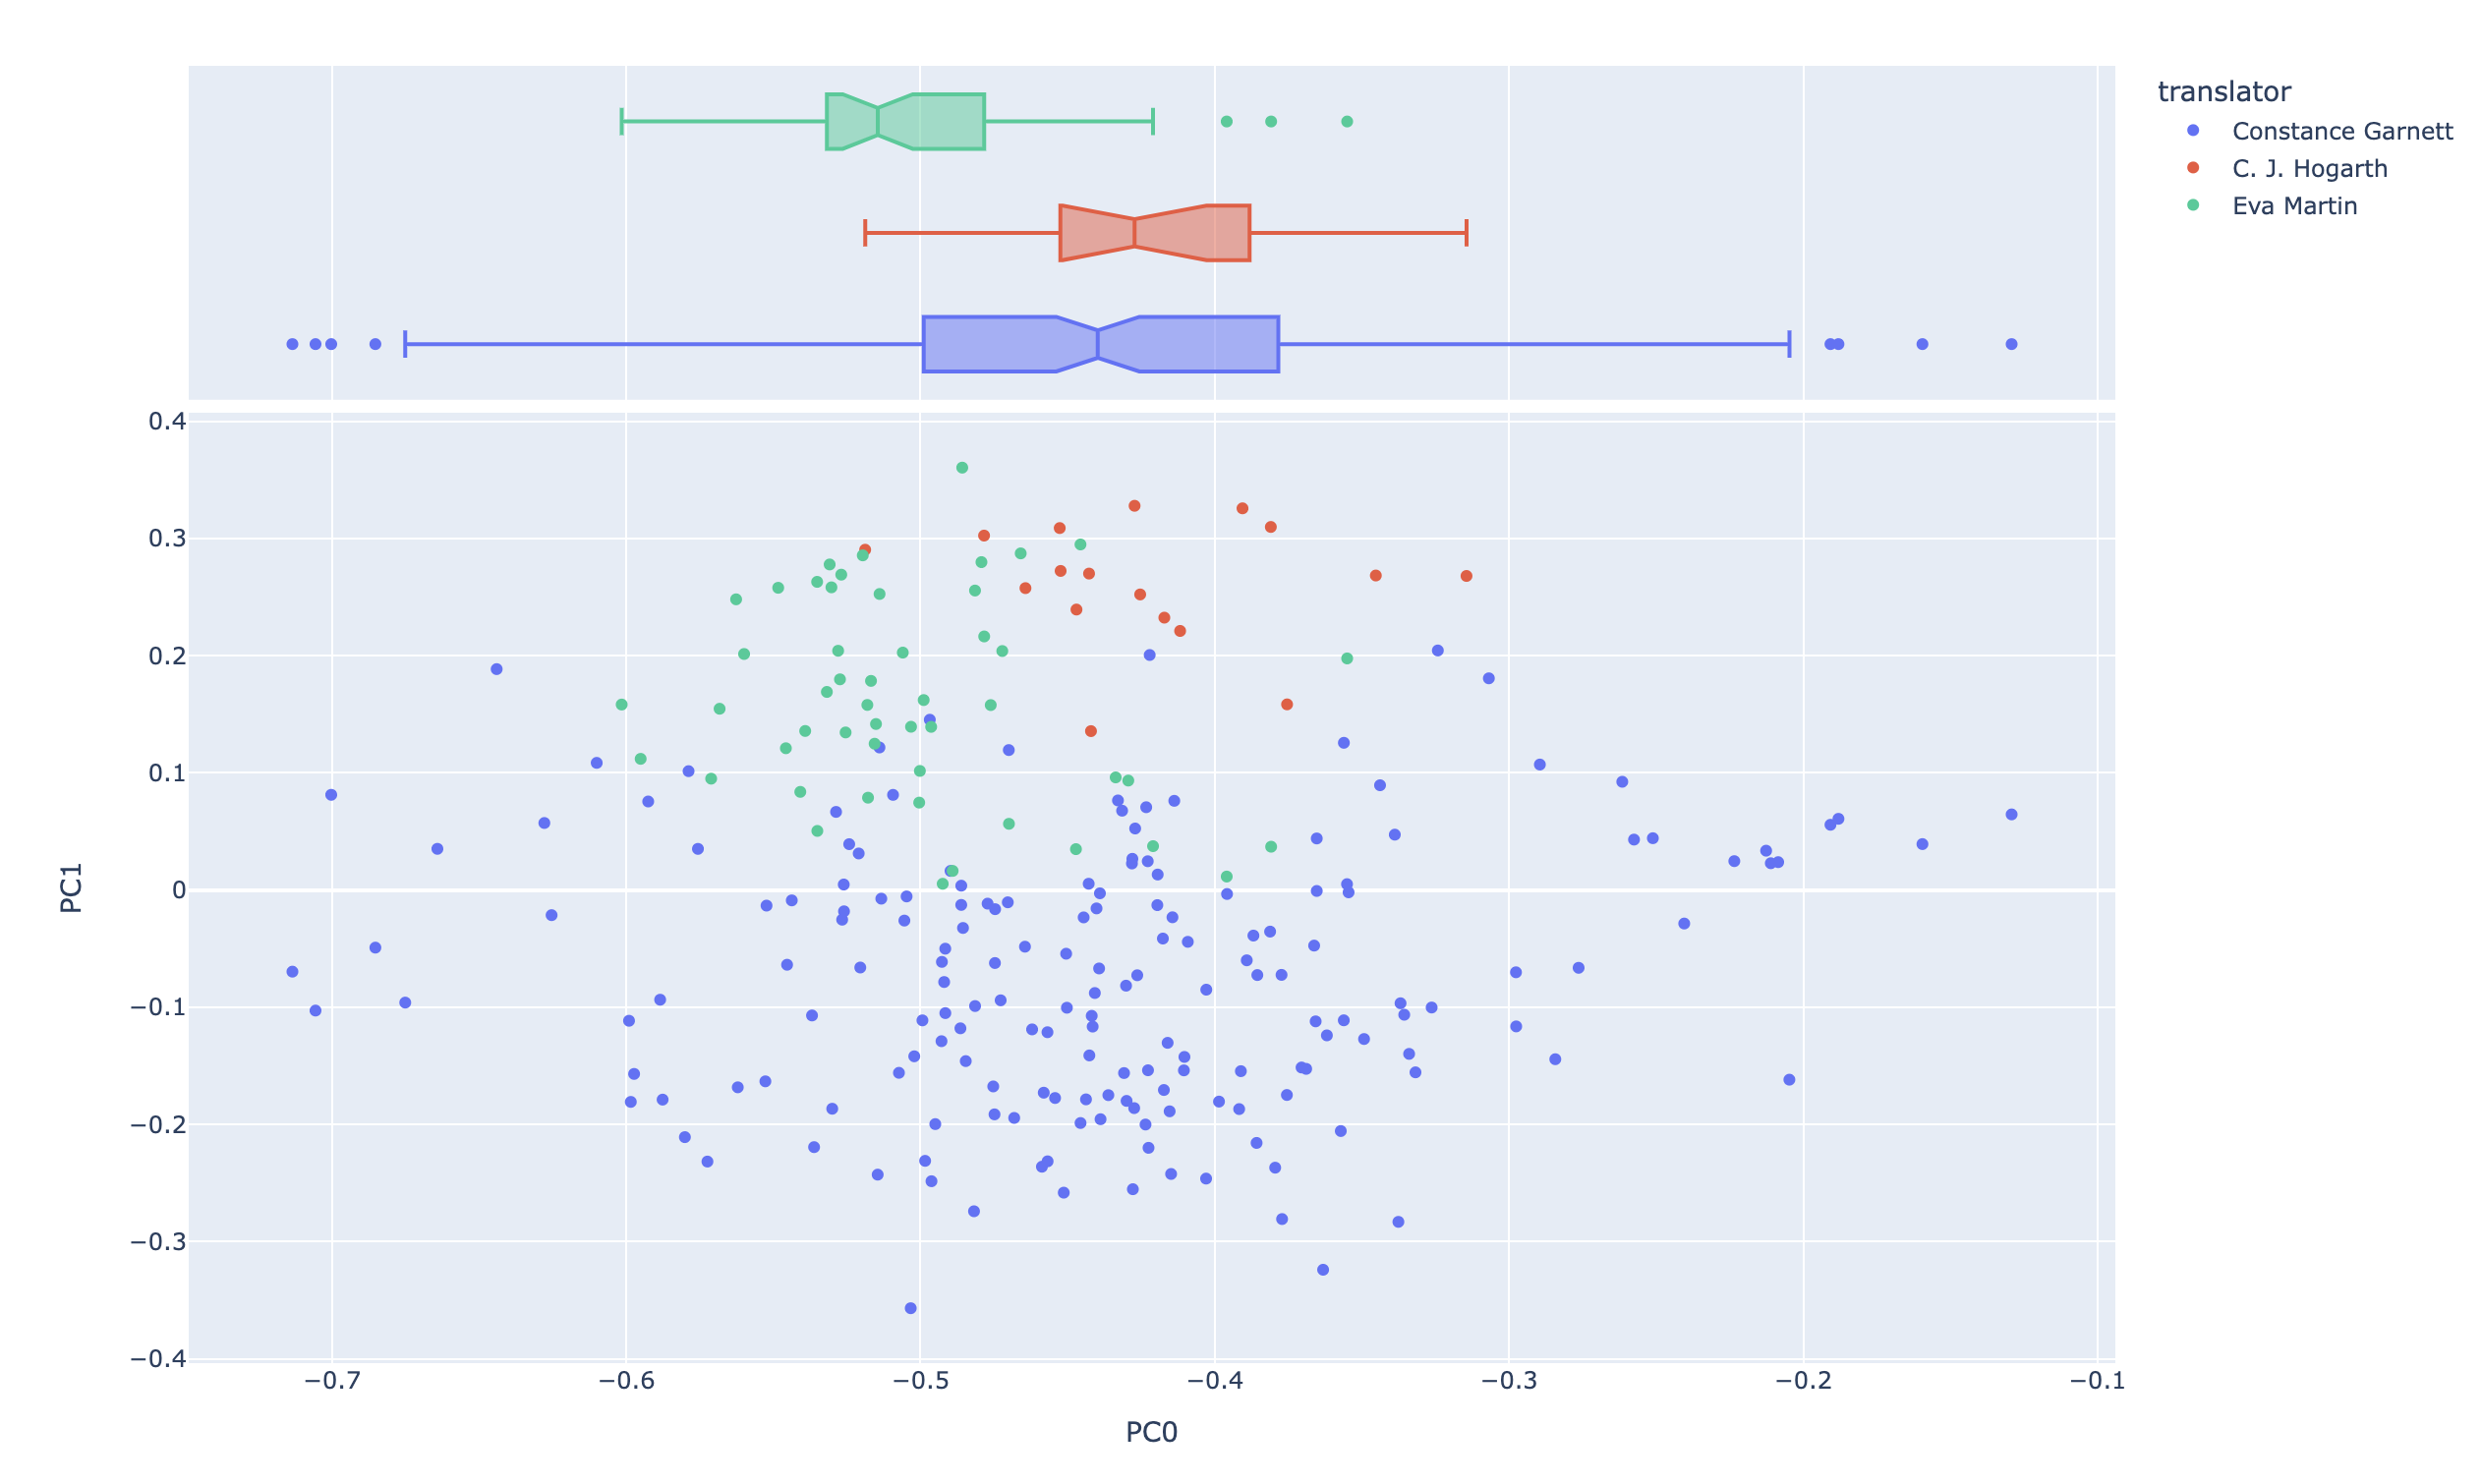

In [3]:
# had to do images this way because the normal way does not let them show up when exporting
from IPython.display import Image
Image(filename='PCA_vis1.png')

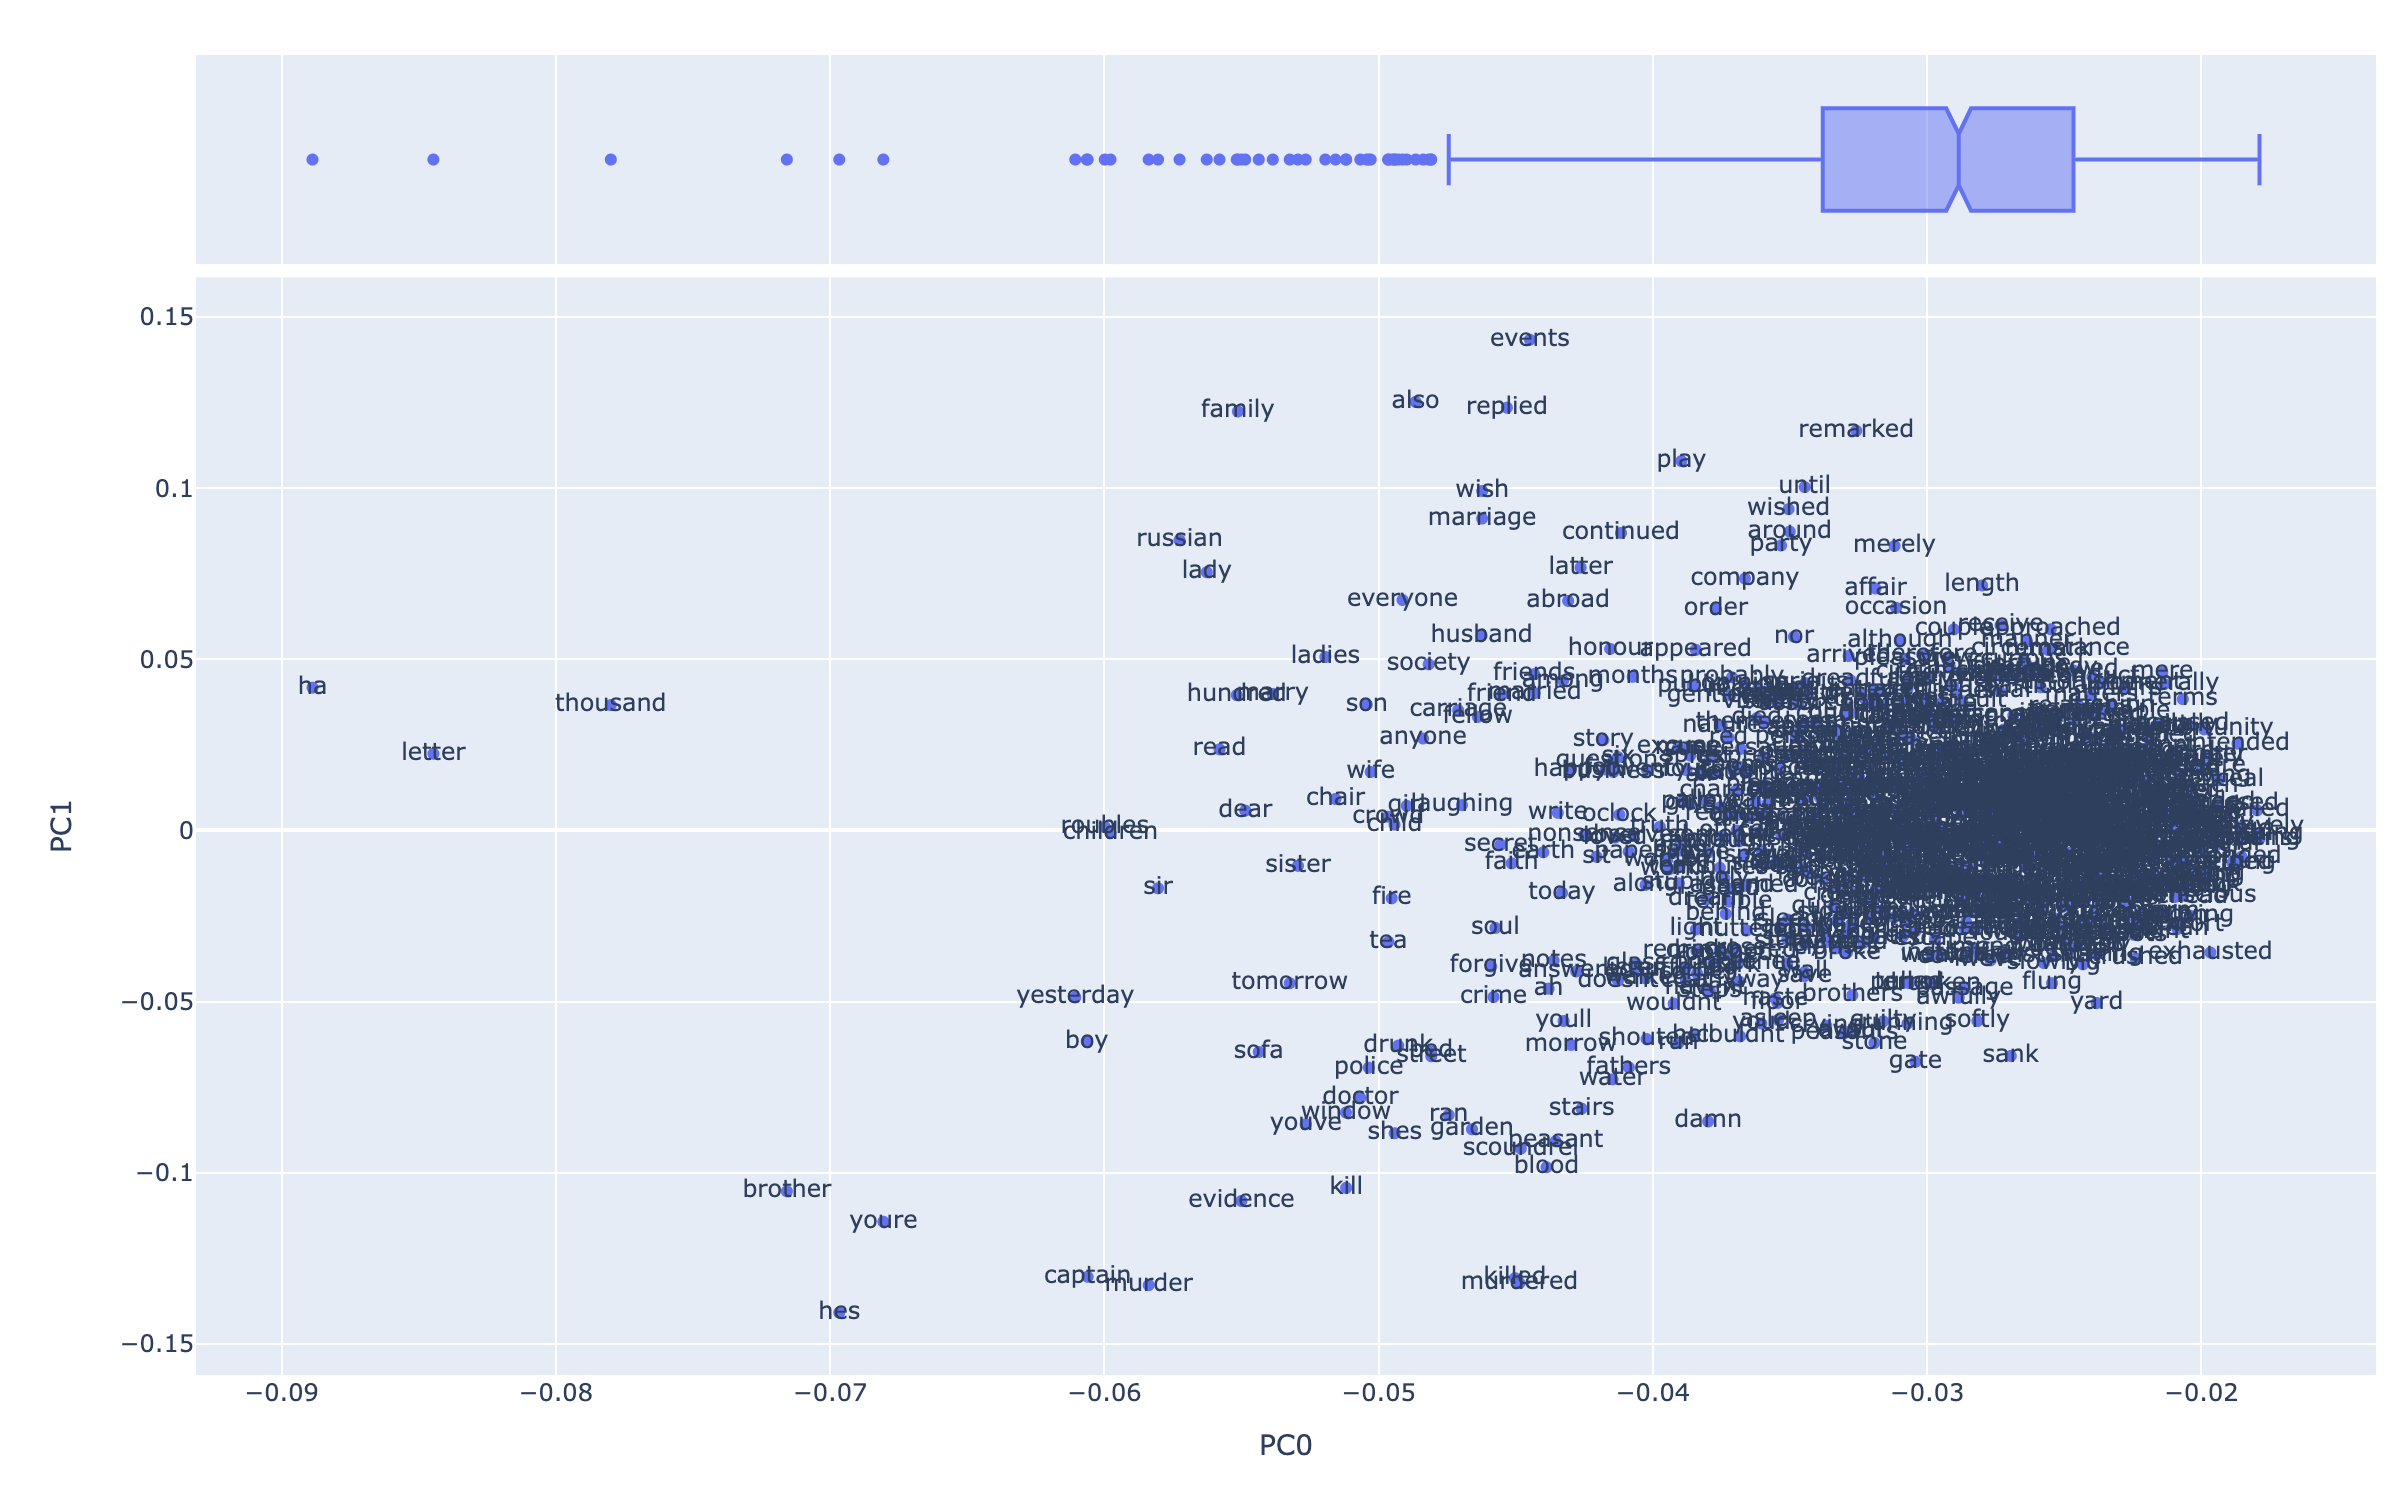

In [4]:
Image(filename='PCA_Loadings1.png')

Briefly describe the nature of the polarity you see in the first component:

**The polarity for the first component can be described as "Daily life vs. stressful situations". On the left, terms like 'letter', 'brother', 'children', 'russian', 'lady', 'family', 'boy' are reminiscent of daily life as they have to do with family and are words commonly used in normal, daily life scenarios. On the right, it is harder to see due to the clustering of the points, but we can see the words 'exhausted', 'failed', 'longed', 'finding', 'conceal', and more. These words are often associated with some level of elevated stress, or some trial that life brings that is out of the ordinary.**

**In terms of the metadata features, it is clear to see that there is some clustering of translators in this component space, although most of it occurs on the PC1 axis and only somewhat on the PC0 axis. This suggests that the texts are highly dependent on the translators' style in how they are interpreted. Different translators may tend to choose terms or phrases to include that change the meaning or tone of Dostoevsky's original work. This is inherent to the art of translation, as there are often several possible ways to say a given phrase in another language.**

## PCA Visualization 2 (4)

Include a scatterplot of documents in the space created by the second two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

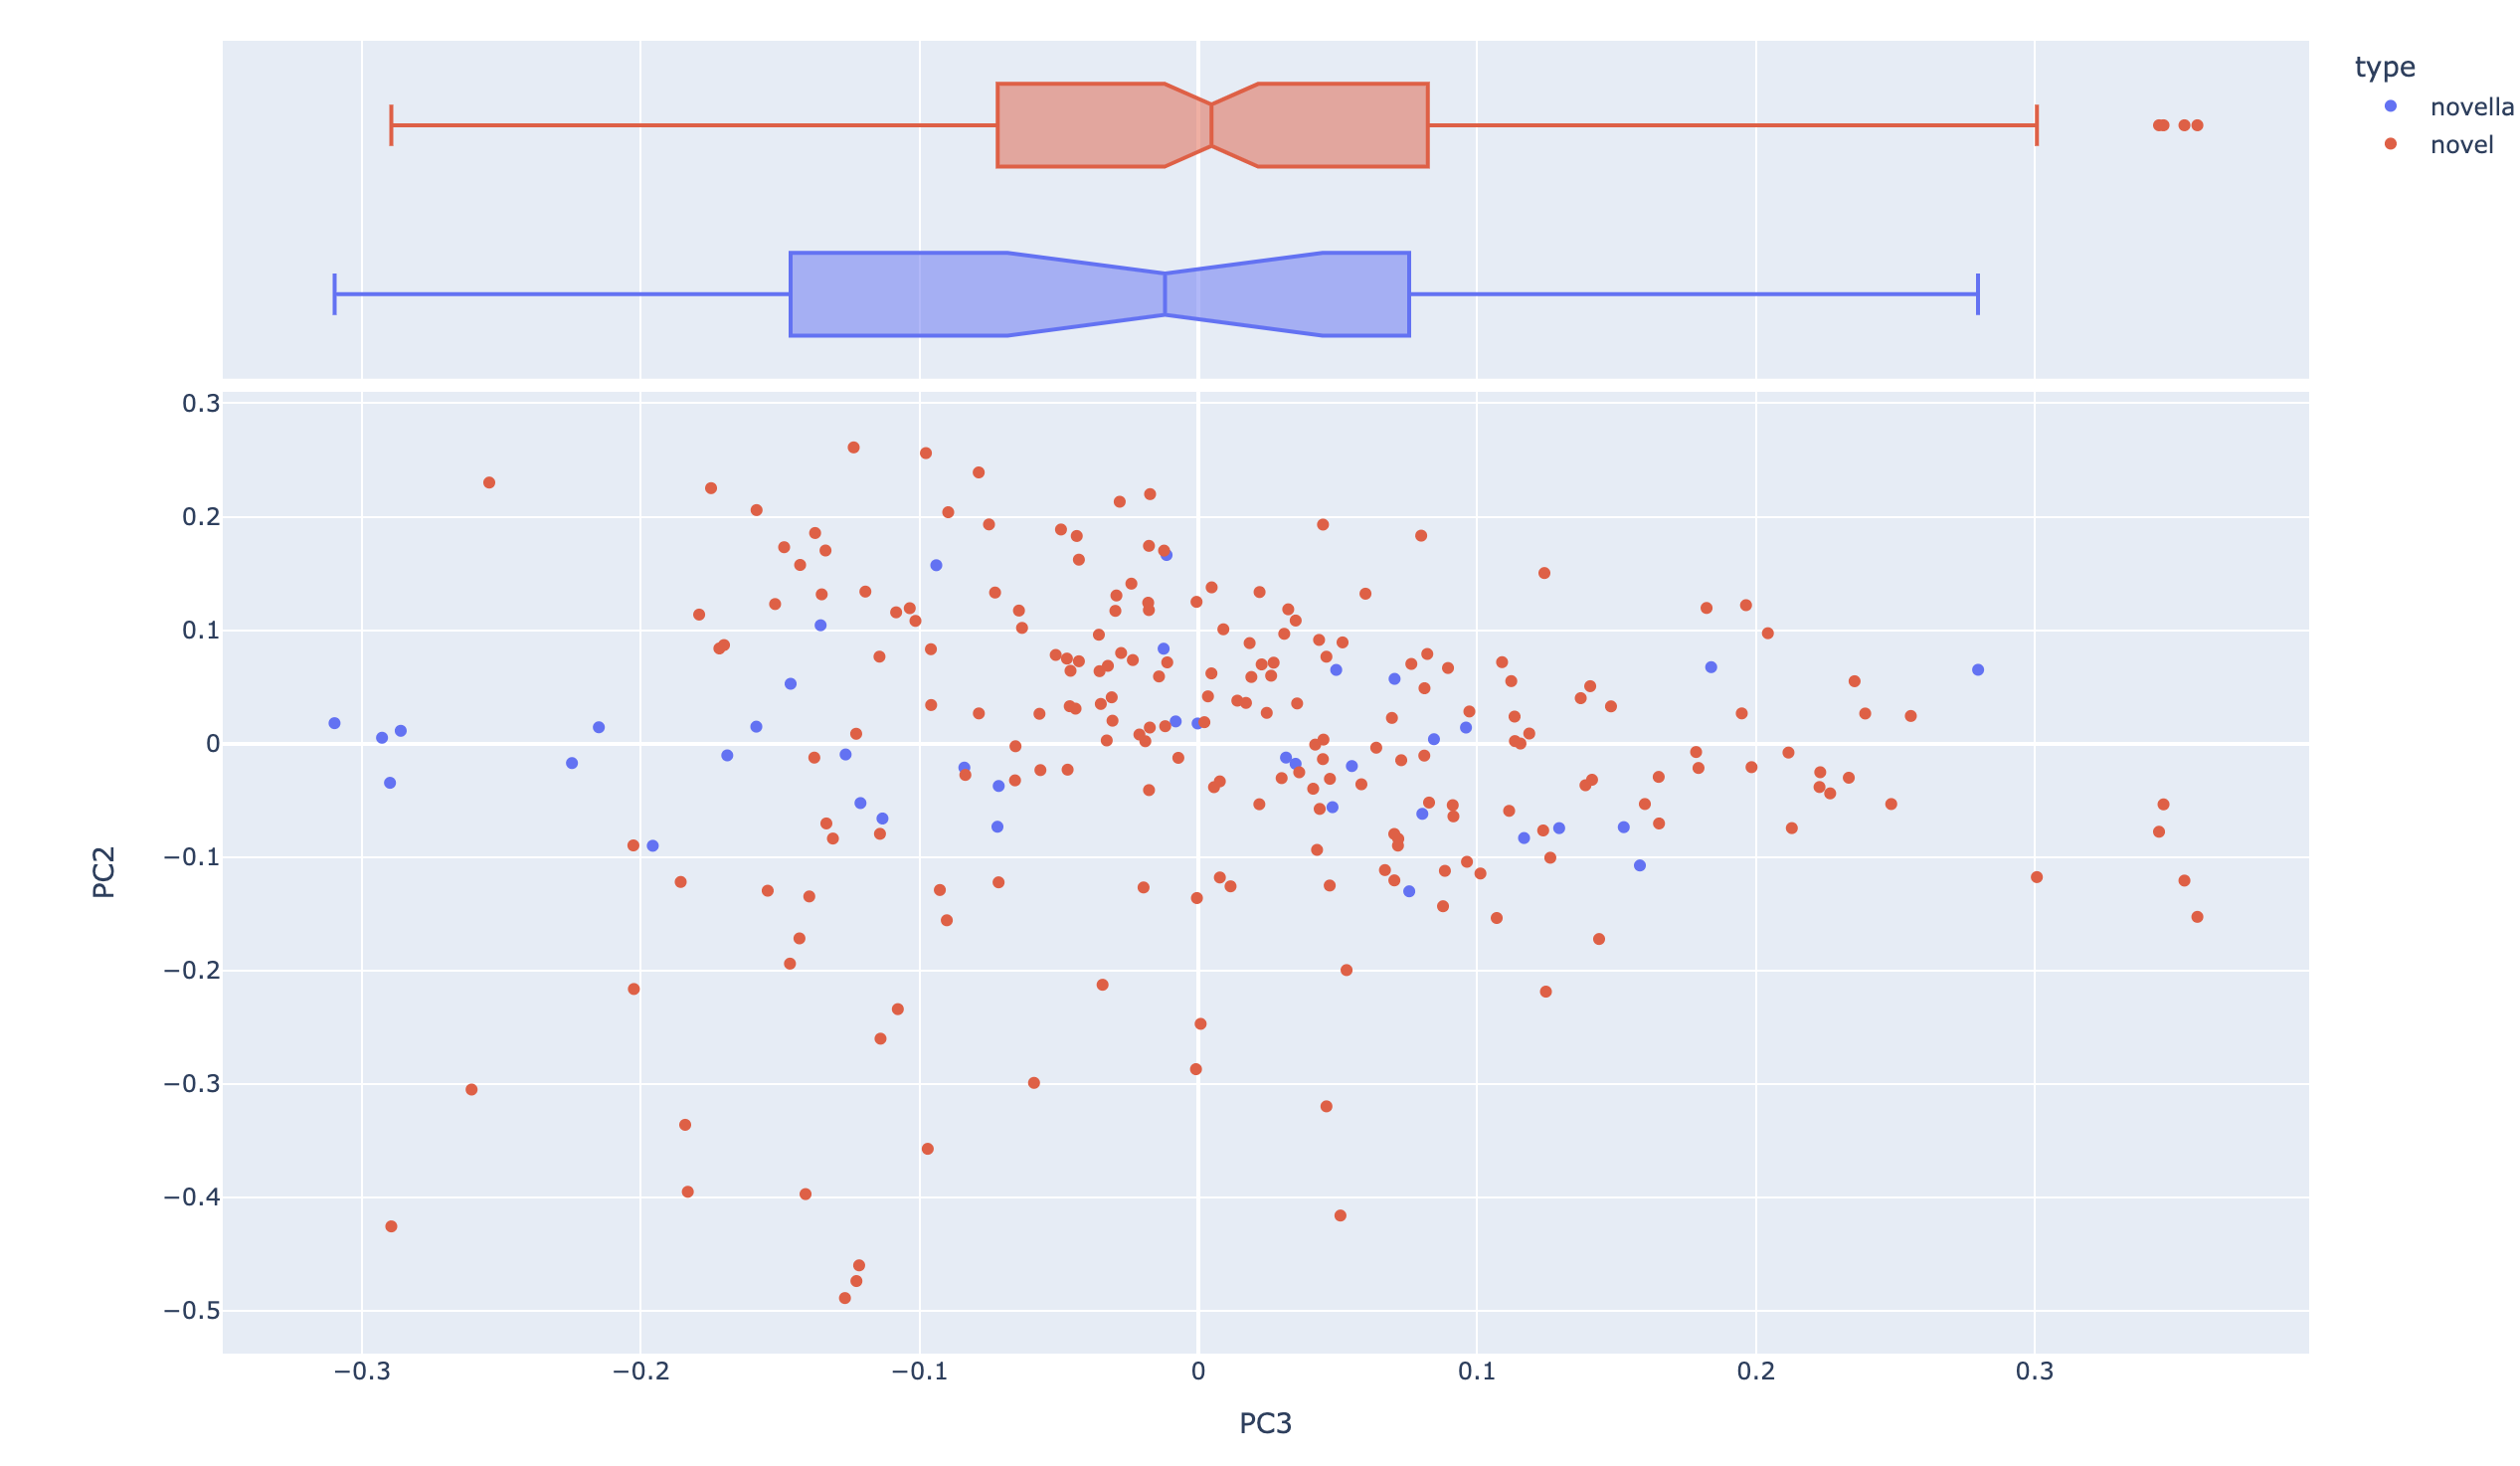

In [5]:
Image(filename='PCA_vis2.png')

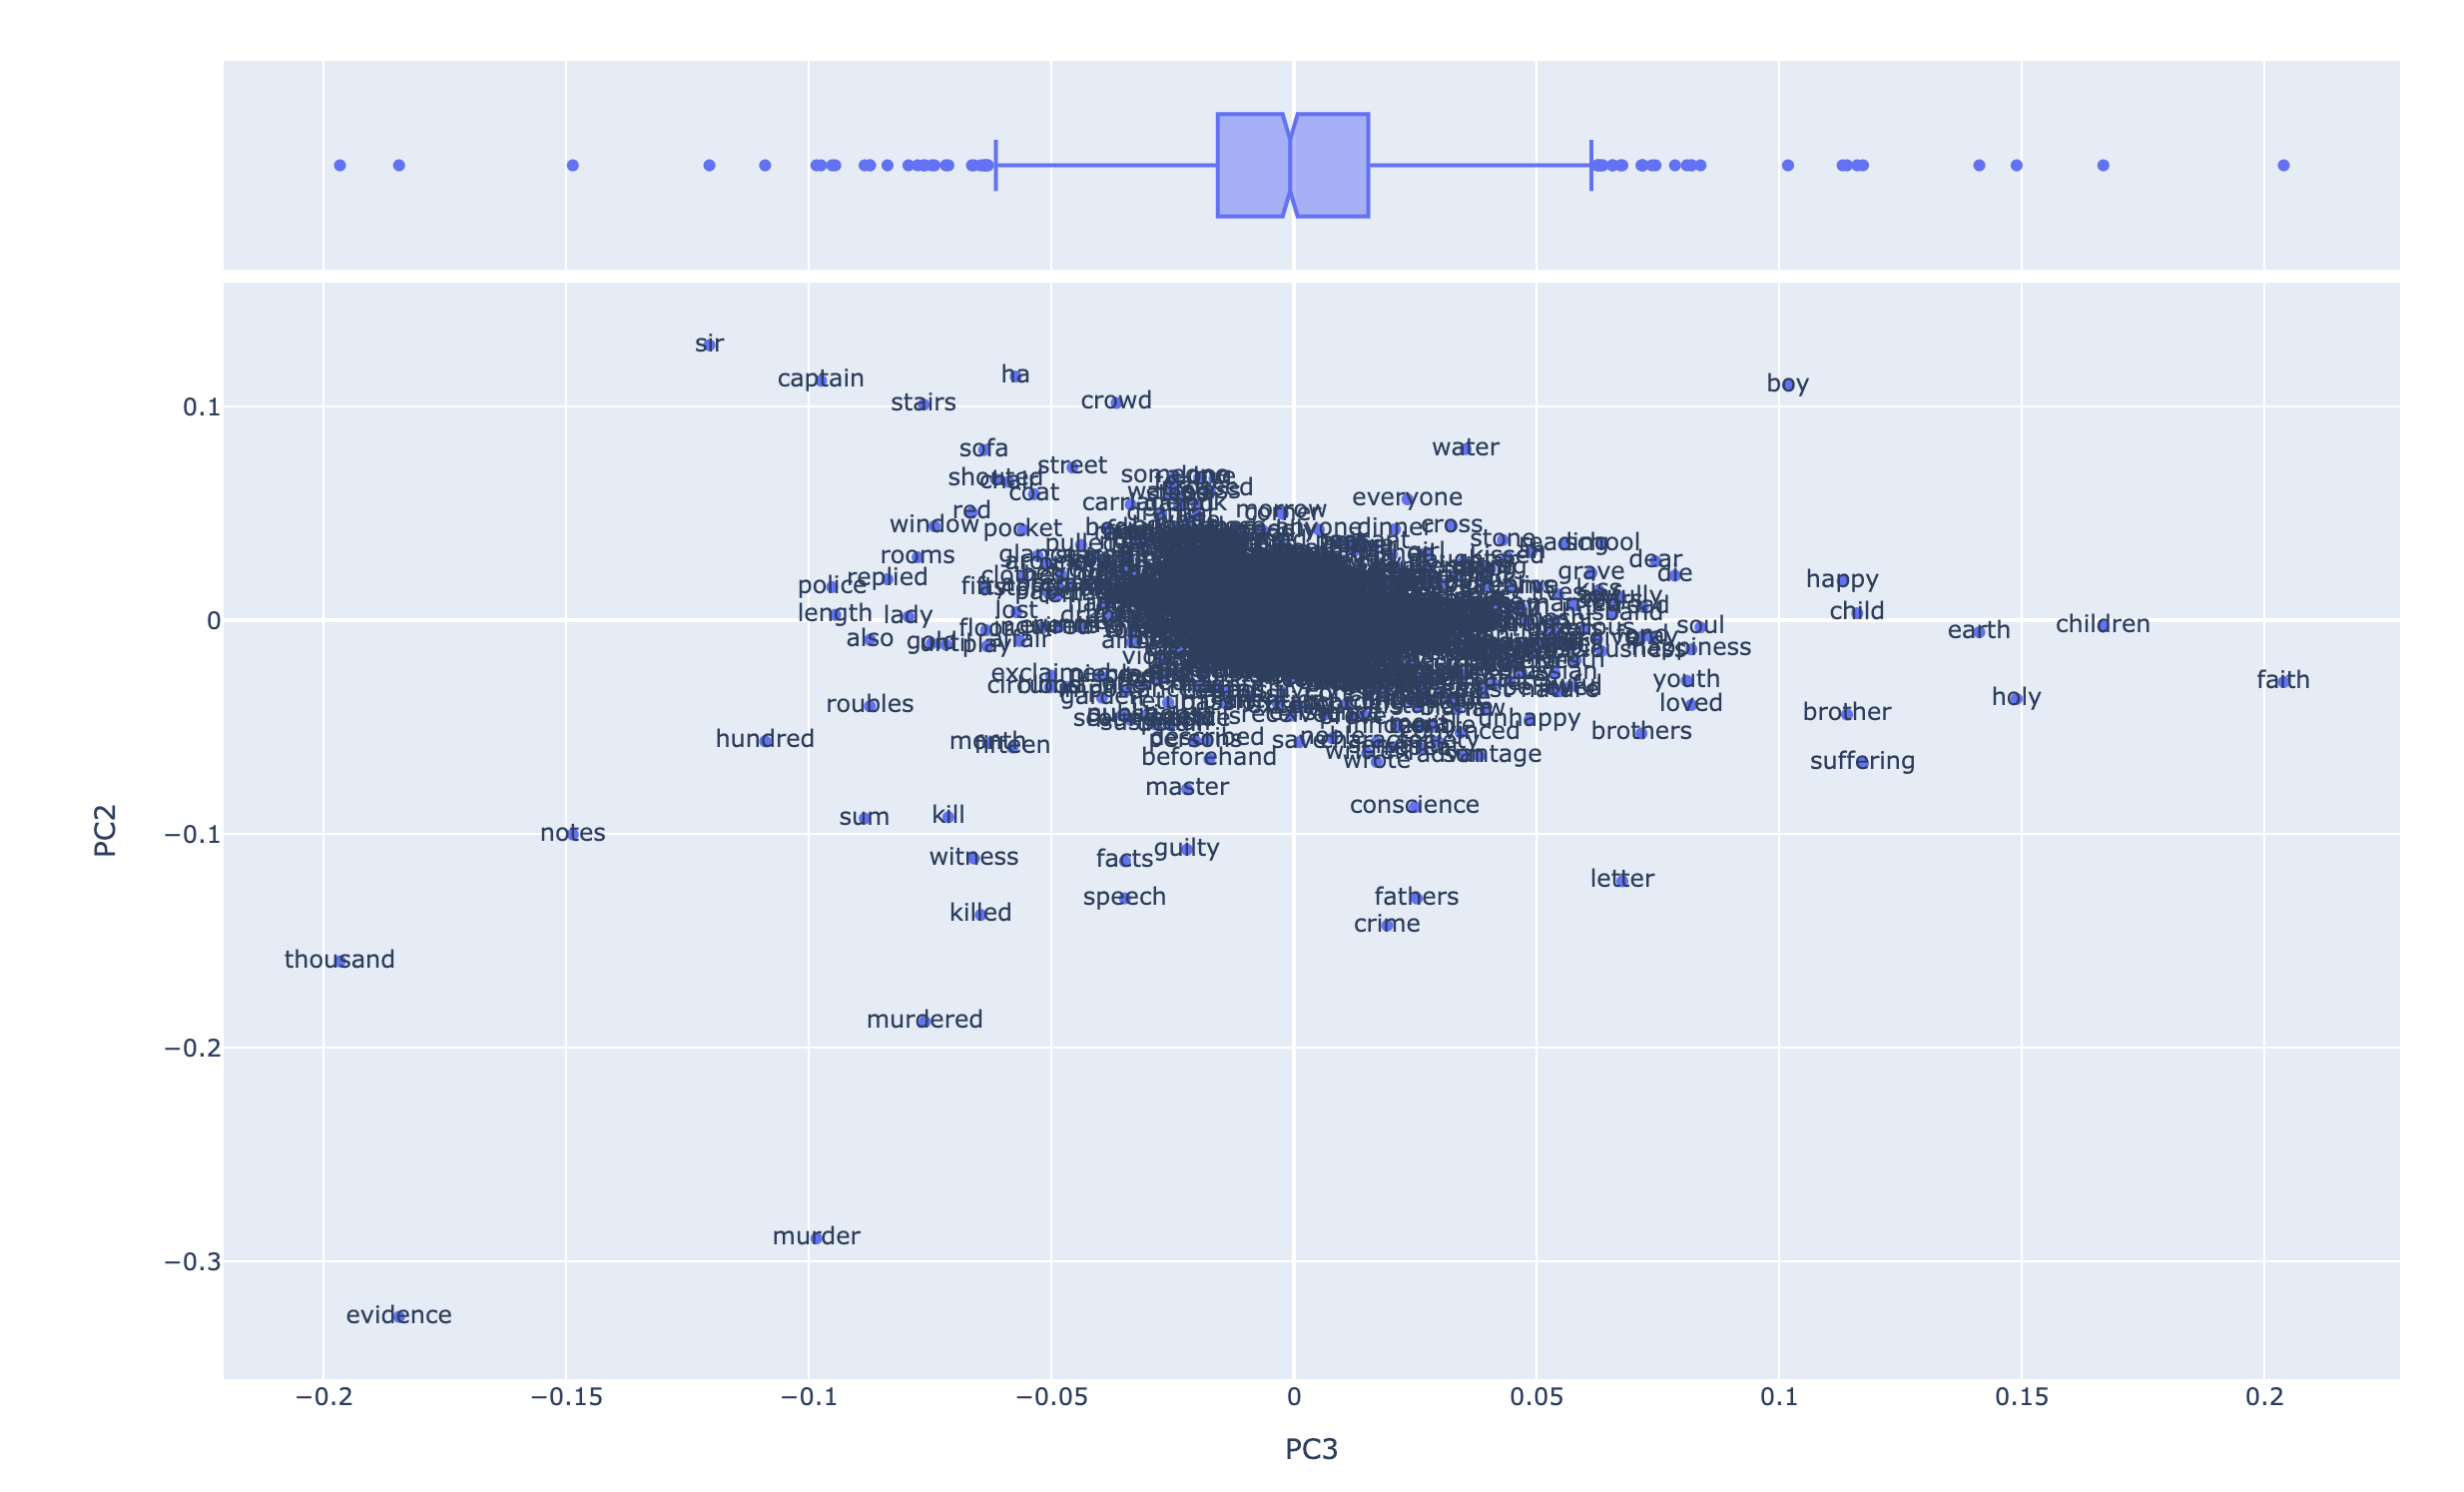

In [6]:
Image(filename='PCA_Loadings2.png')

Briefly describe the nature of the polarity you see in the second component:

**The polarity in PC3 (the second out of the "second two" that this plot is supposed to show) can be defined as "money/crime vs. purity." On the left we see murder, kill, witness, police, which are all associated with crime, and we also see thousand, hundred, notes, sum, roubles, which are associated with money. This combination makes sense, because money is a well-known common motivation for crime. On the right, we see faith, holy, children, happy, youth, which are all associated with purity and goodness. Suffering is sort of an outlier, however this is a common word used in religious context, so it may still fit into the category.**

**Of note, we see that there is practically no distinction between novels and novellas in this component space, indicating that Dostoevsky's work was perhaps consistent regardless of the format he was writing in.**

## LDA TOPIC (4)

- UVA Box URL: https://www.dropbox.com/scl/fi/aa2j44d0b8a28ao6rmyq3/dostoevsky-LDA_TOPIC.csv?rlkey=afxwts7fne12tn5abndn4ku1j&st=ejrti483&dl=0
- UVA Box URL of count matrix used to create: https://www.dropbox.com/scl/fi/mfxo07dazubsi46fq2jnd/dostoevsky-LDA_DOCS.csv?rlkey=ndh53pi47bj81hxk3qqx5iavo&st=smmt0jmv&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**
- Libary used to compute: **SciKitLearn**
- A description of any filtering, e.g. POS (Nouns and Verbs only): **I filtered down to only keep nouns, and not proper nouns (pos.str.match(r'^NNS?$'). I also removed the term "prince," because in Dostoevsky's *The Idiot,* the main character is called "the prince" or "prince" so often that it essentially functions as a proper noun.**
- Number of components: **20 topics**
- Any other parameters used:

ngram_range = (1, 2)

n_terms = 4000

n_topics = 20

max_iter = 5

n_top_terms = 7

- Top 5 words and best-guess labels for topic five topics by mean document weight:
  - T11: **yes eyes face smile man**
      - **best-guess label: The face (particularly when giving affirmation / saying yes)**
  - T16: **room door table chair note**
      - **best-guess label: space in a home / typical features of a room**
  - T04: **life years time woman man**
      - **best-guess label: marriage / home life**
  - T06: **letter brother word hand answer**
      - **best-guess label: correspondence through writing / between brothers or family members**
  - T02: **oh people men man hands**
      - **best-guess label: Humans, using 'men' to refer to people**

## LDA THETA (4)

- UVA Box URL: https://www.dropbox.com/scl/fi/1ltg6wo7stwt6cb1t6odf/dostoevsky-LDA_THETA.csv?rlkey=luxukua5r9aowmilpmwh1et4e&st=x8rxa207&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**

## LDA PHI (4)

- UVA Box URL: https://www.dropbox.com/scl/fi/qz6fmuhg2od8l4auj37o8/dostoevsky-LDA_PHI.csv?rlkey=3r6uf3i7y4qzbxq5yh9m2rndi&st=048k7lnk&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**

## LDA + PCA Visualization (4)

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

Provide a brief interpretation of what you see.

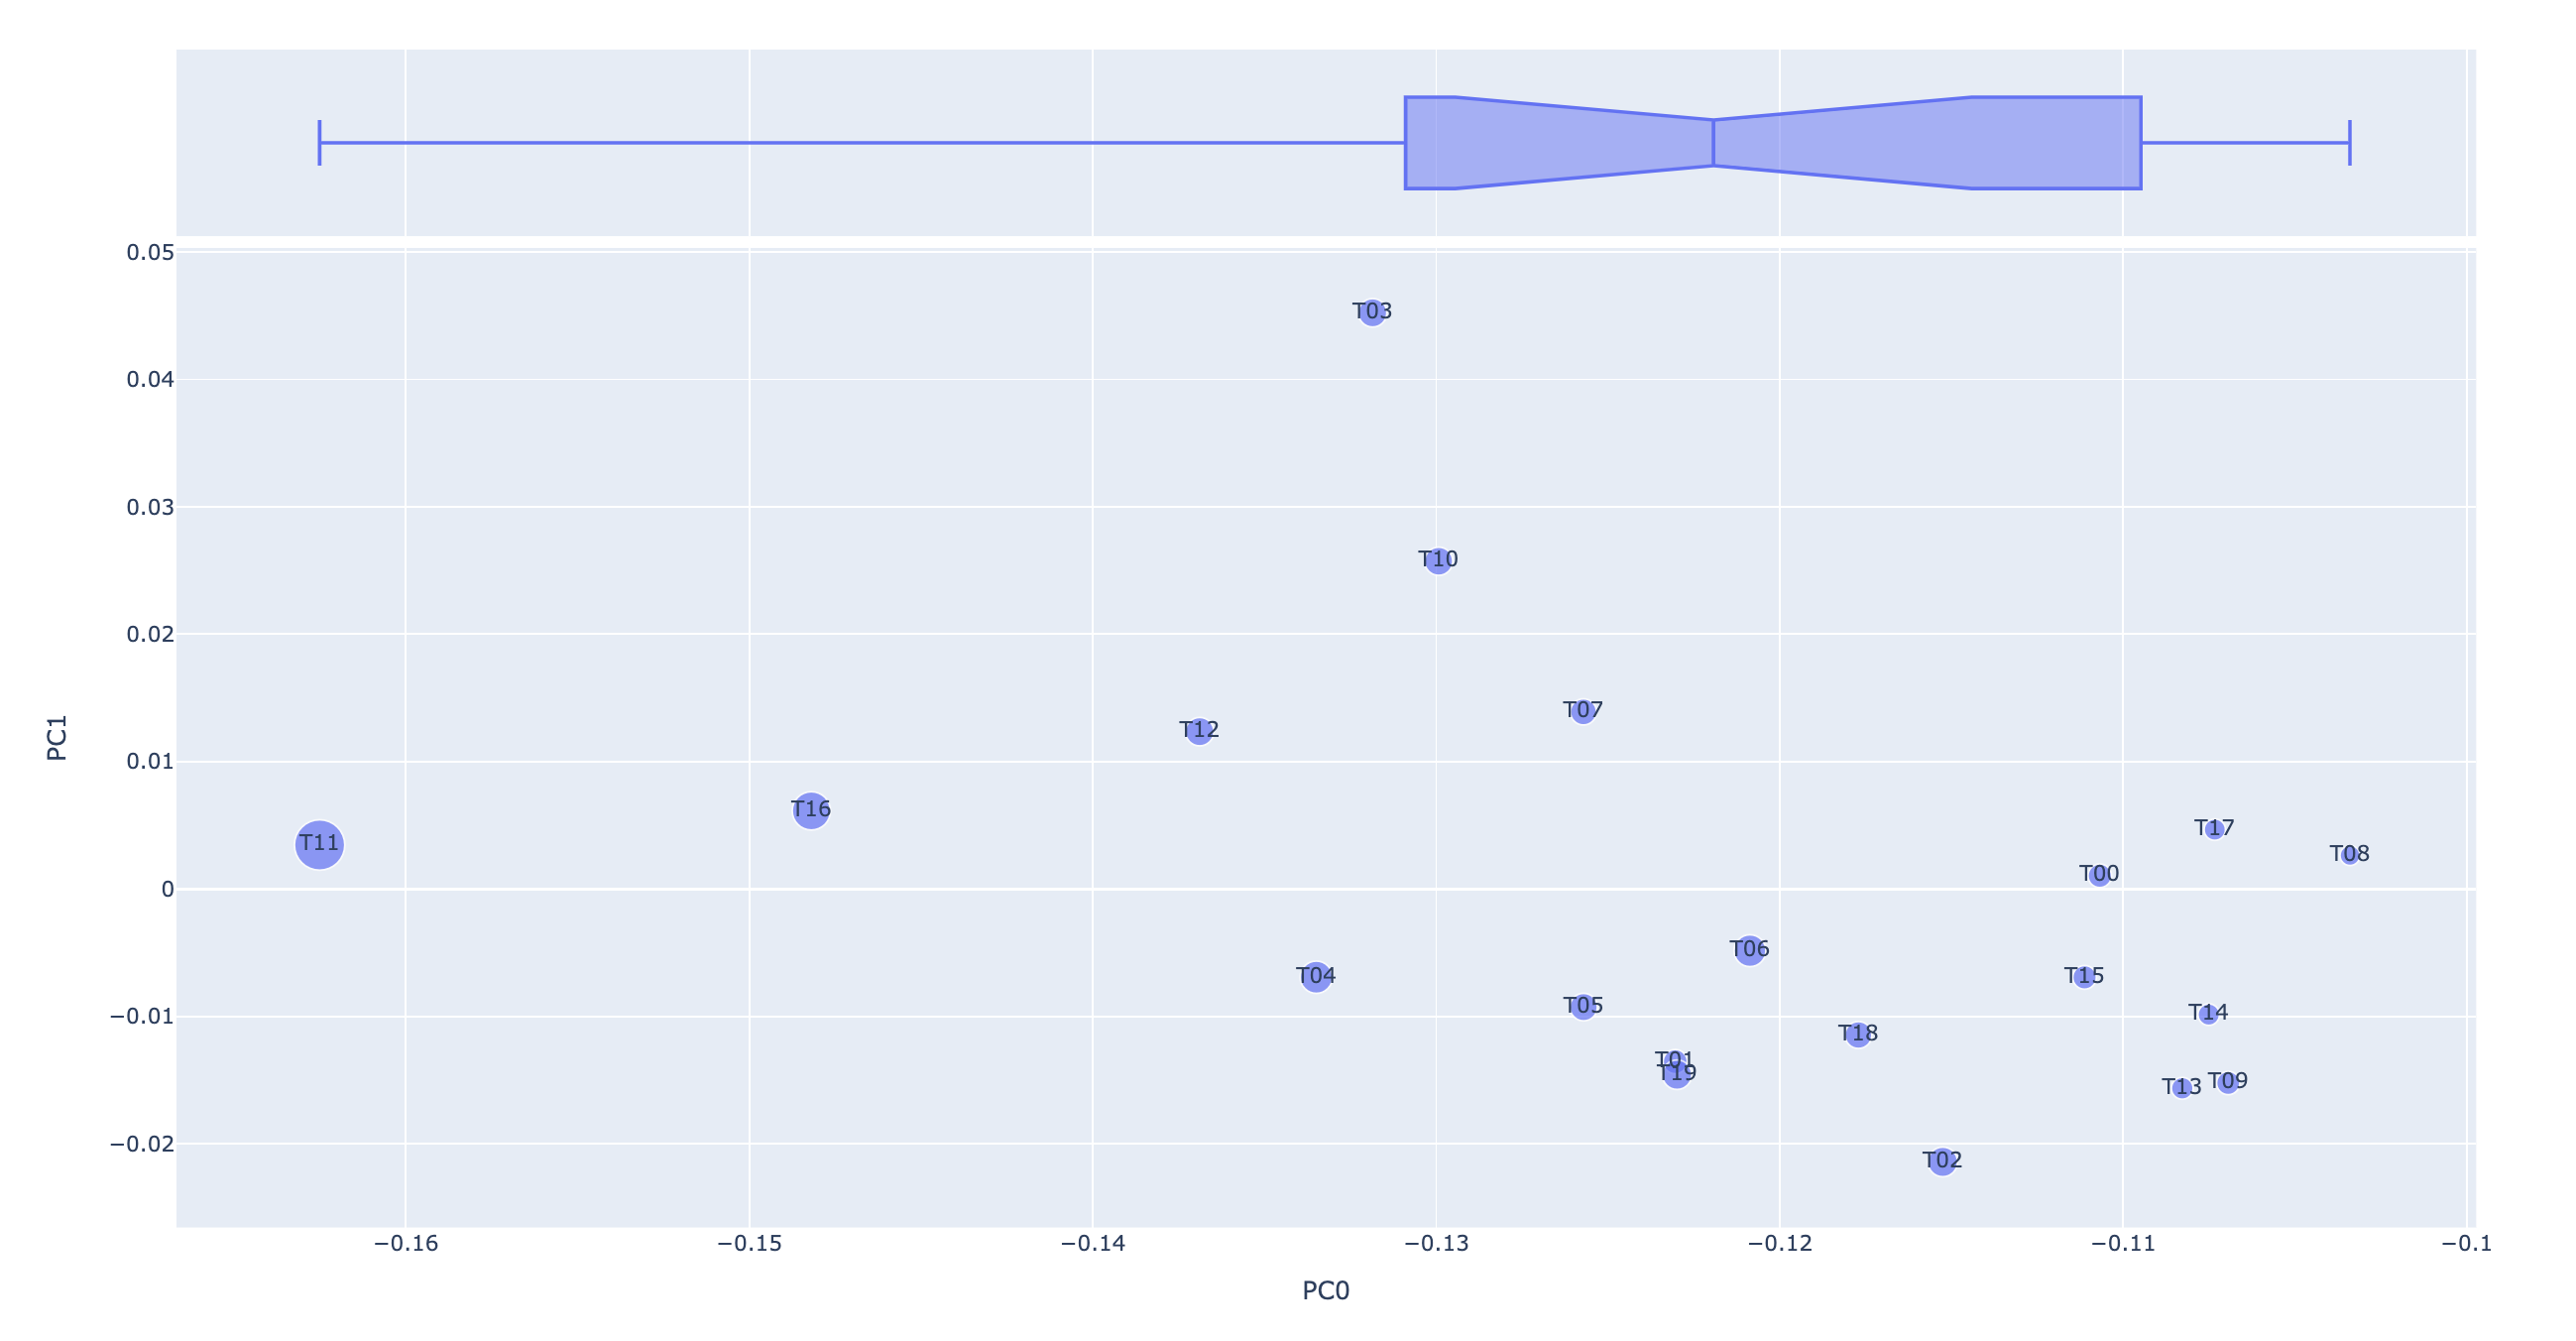

In [7]:
Image(filename='LDA_PCA1.png')

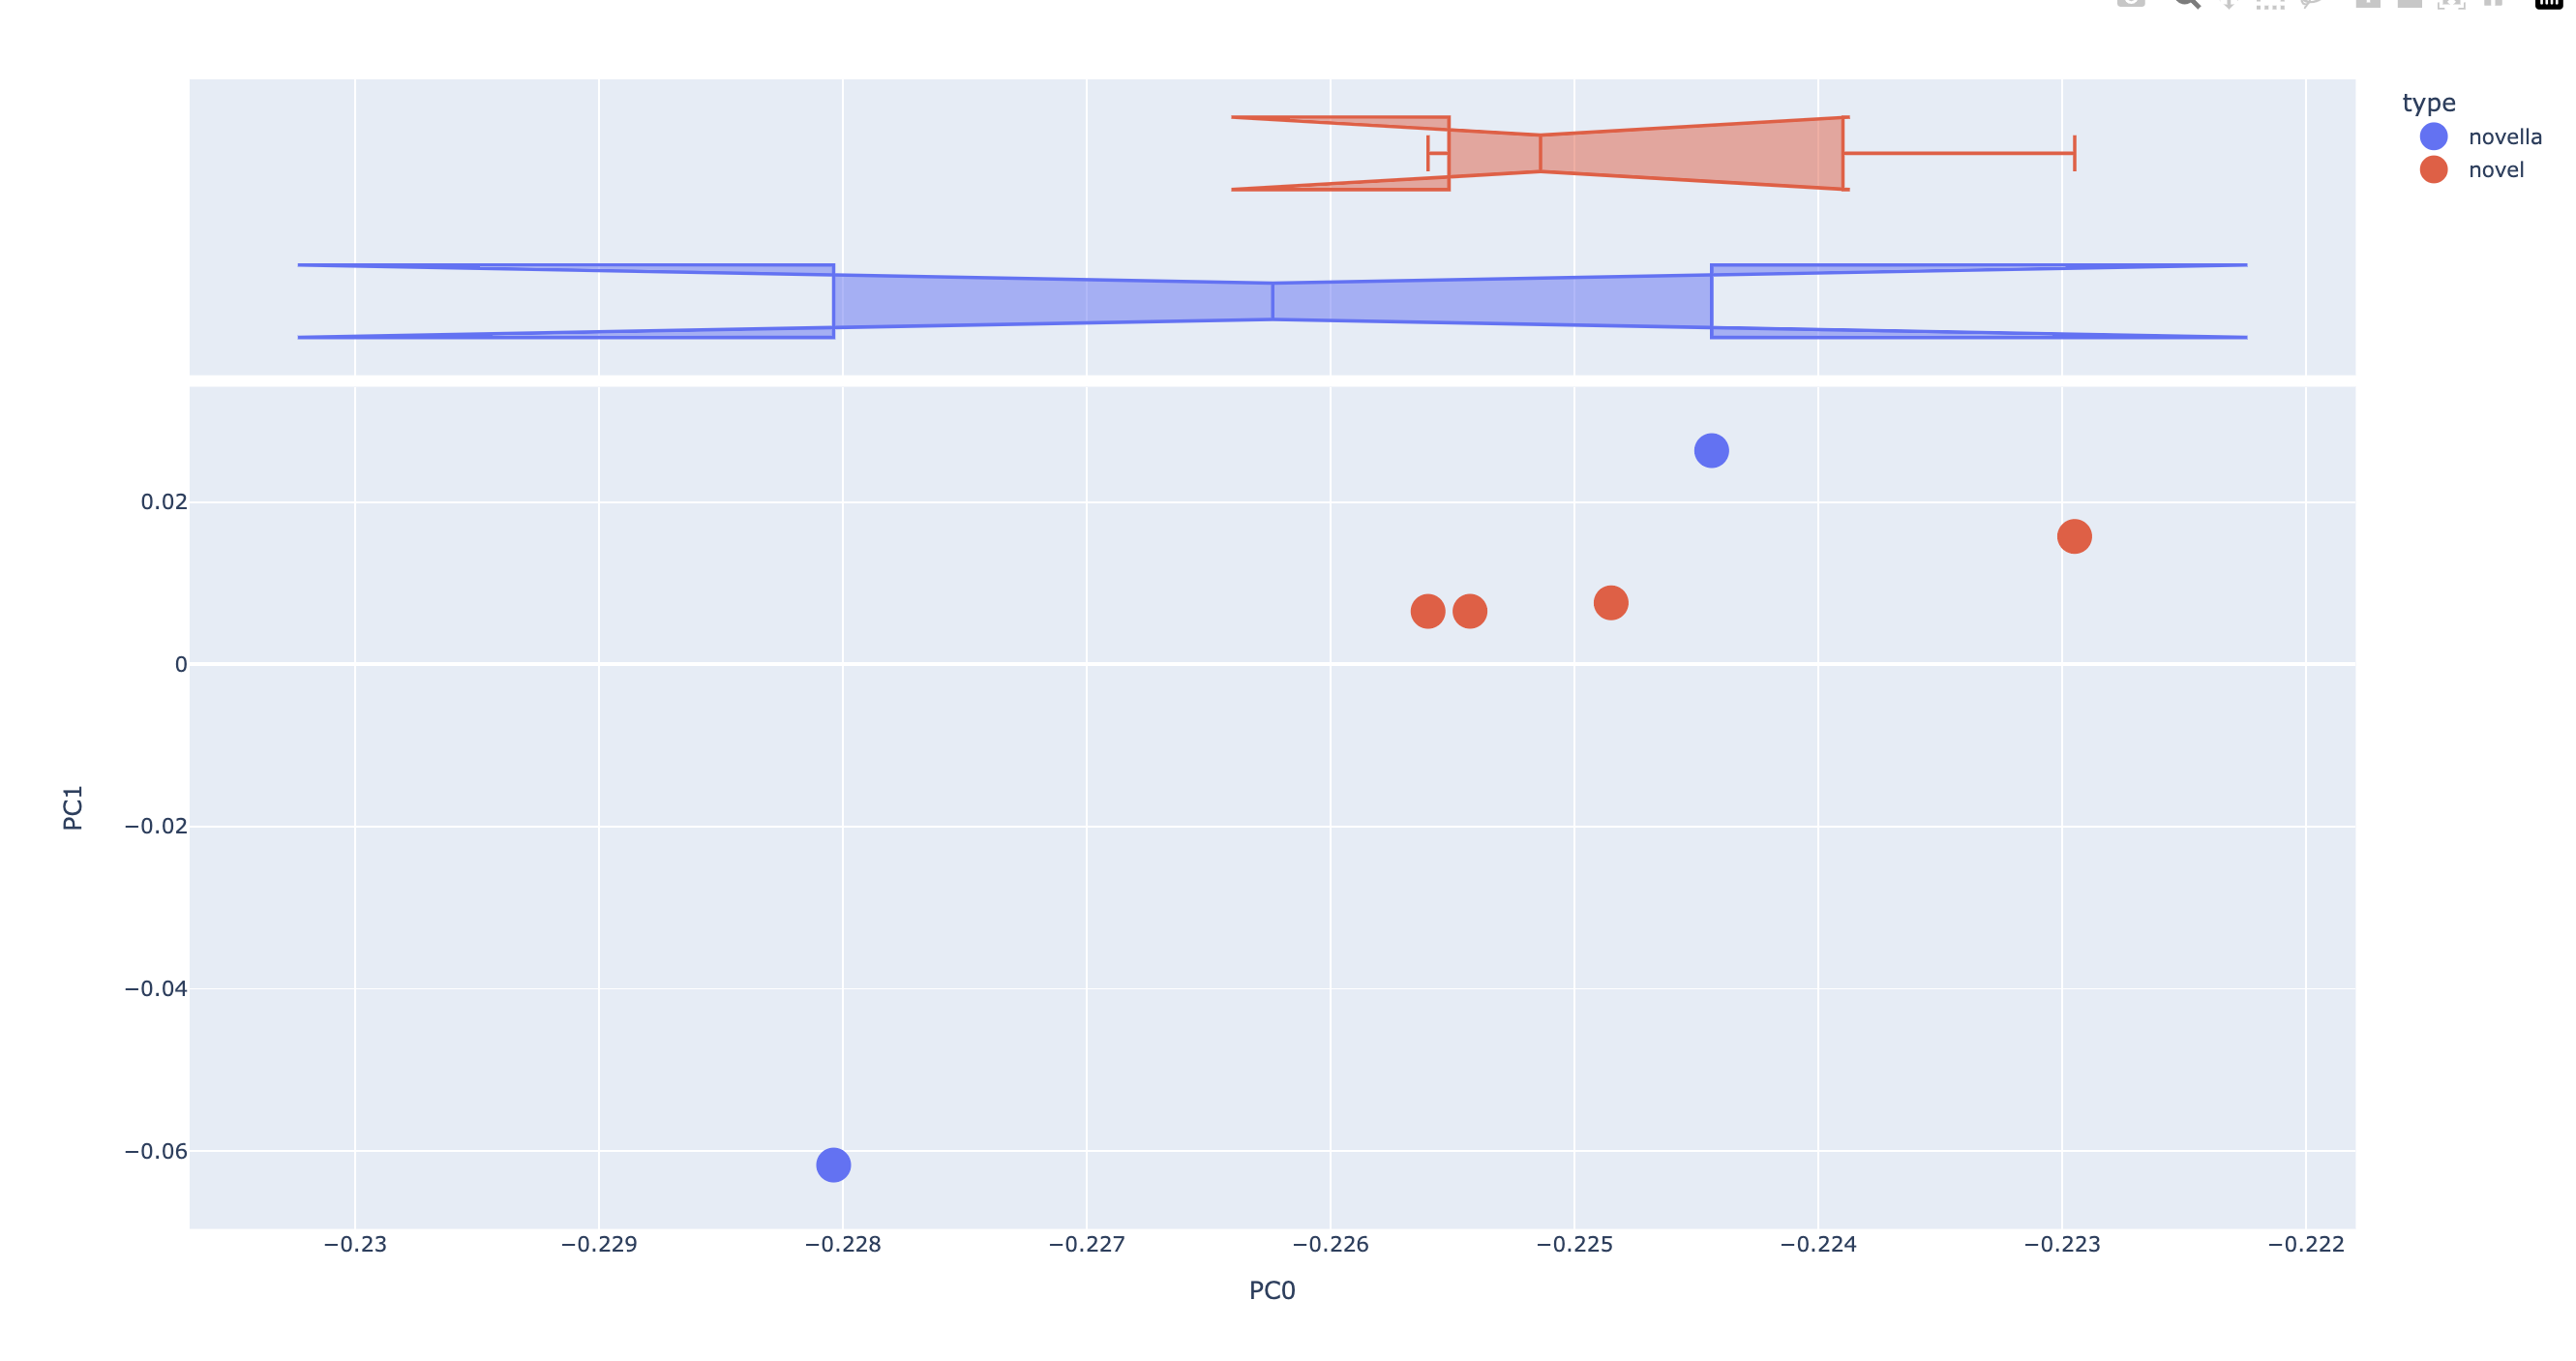

In [8]:
Image(filename='LDA_PCA2.png')

**Note: For this question, I was not able to figure out how to plot the topics but also color the points by a LIB feature, since the table I was plotting had topics as the rows and PCs as the columns. However, I did PCA on two differnt things- the THETA table as normal and the THETA table transposed, so that with the second one I could color the points by a LIB feature. I am not sure if this is the intended approach, but as I said I was not sure how to incorporate all of the requirements for this question onto one plot, as it would require more information than is store in the table produced by running PCA on THETA.**

**In terms of interpretation: We can see that the topics are mainly clustered towards the right on the PC0 axis, however they seem to get generally smaller as they move from left to right. This indicated that the topics that have higher document weights on average tend to have lower values in PC0 space. This is an interesting pattern and suggests that PC0 is based at least somewhat on the impact that these topics have within the corpus.**

## Sentiment VOCAB_SENT (4)

Sentiment values associated with a subset of the VOCAB from a curated sentiment lexicon.

- UVA Box URL: https://www.dropbox.com/scl/fi/tt18ciewf56s305dlqf1h/dostoevsky-VOCAB_SENT.csv?rlkey=9ybtc8lwlz9ixxiy61qnhi8ix&st=xhnjmnd6&dl=0
- UVA Box URL for source lexicon
    - SALEX table that I made: https://www.dropbox.com/scl/fi/7i778pvghnd7ql8hjyhkz/dostoevsky-SALEX.csv?rlkey=5o646vlo54vo012jmrgmbxs8a&st=tb1xagfm&dl=0
    - Original Lexicon csv: https://www.dropbox.com/scl/fi/2hzknwrga3rwzz6omzhr9/salex_nrc.csv?rlkey=eacuntnw41gq2g2imdm6bwqhv&st=l9gid4a1&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**

## Sentiment BOW_SENT (4)

Sentiment values from VOCAB_SENT mapped onto BOW.

- UVA Box URL: https://www.dropbox.com/scl/fi/ziwjibjgj2ri84ootlnvv/dostoevsky-BOW_SENT.csv?rlkey=2ucx00a9rwq66bi6ij8eebclp&st=x9ewfc0k&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**

## Sentiment DOC_SENT (4)

Computed sentiment per bag computed from BOW_SENT.

- UVA Box URL: https://www.dropbox.com/scl/fi/64nvmb6y6a72zn7fubs0y/dostoevsky-DOC_SENT.csv?rlkey=43cvpa5k9blfky4hxex2fcs23&st=05e1uof0&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**
- Document bag expressed in terms of OHCO levels: **book_id, chap_id**

## Sentiment Plot (4)

Plot sentiment over some metric space, such as time.

If you don't have a metric metadata features, plot sentiment over a feature of your choice.

You may use a bar chart or a line graph.

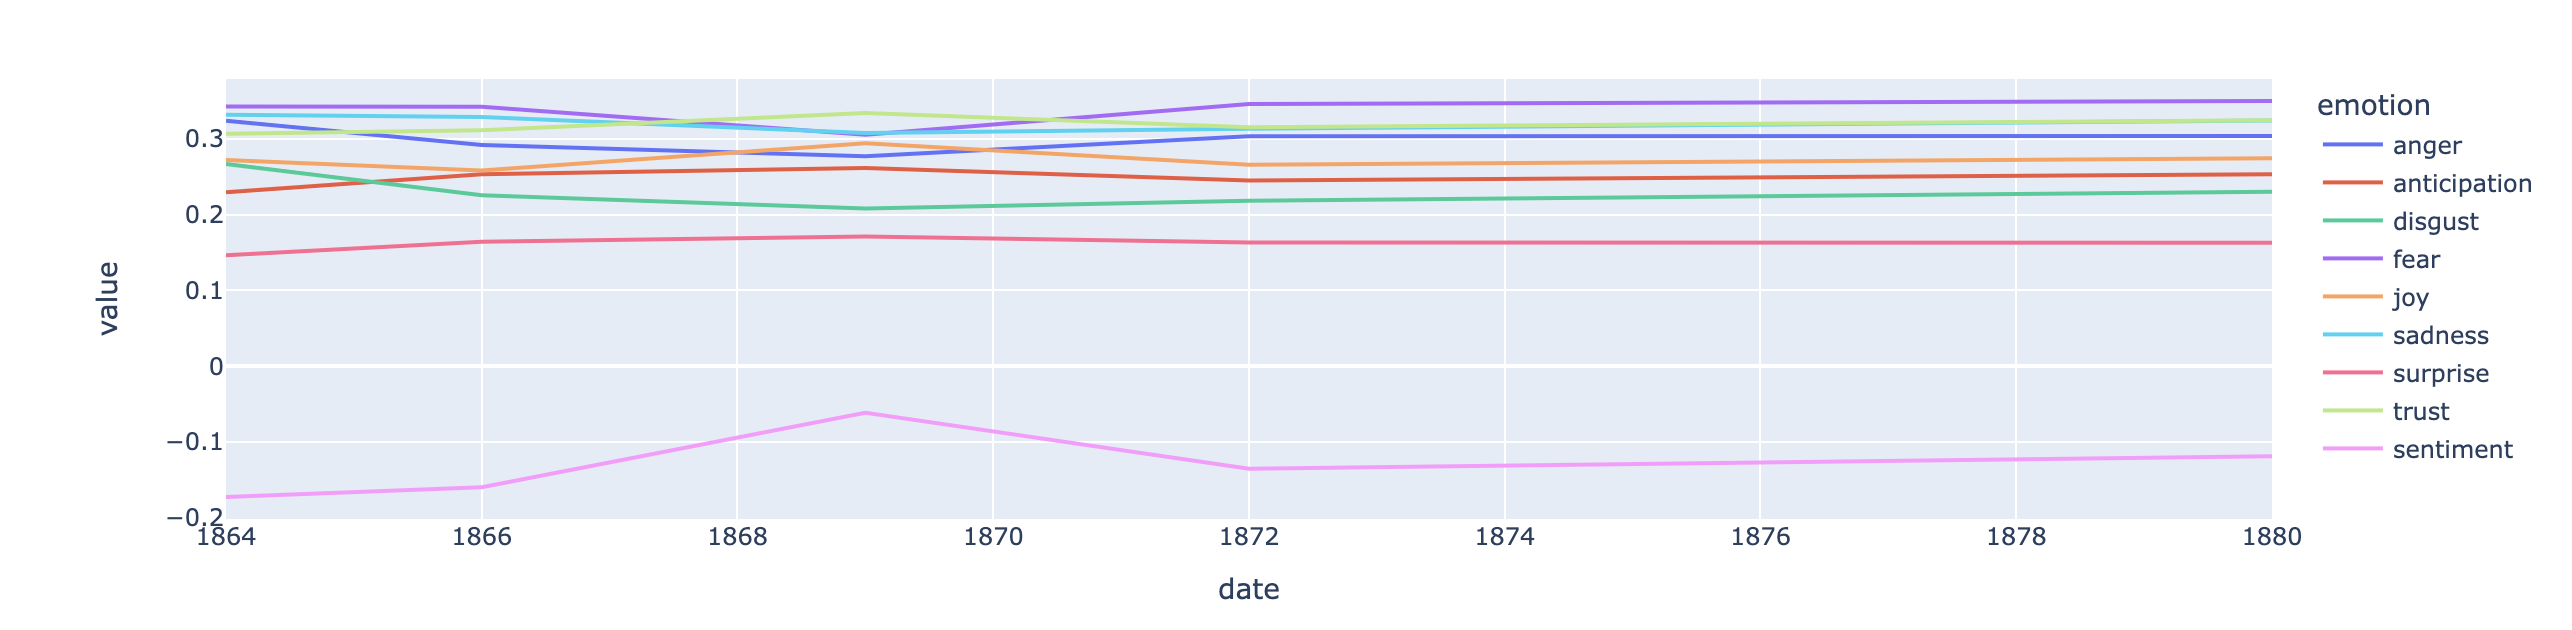

In [9]:
Image(filename='sent_plot.png')

## VOCAB_W2V (4)

A table of word2vec features associated with terms in the VOCAB table.

- UVA Box URL: https://www.dropbox.com/scl/fi/4oyb5im4g64w350nqpnvh/dostoevsky-VOCAB_W2V.csv?rlkey=w9soiwv7bt010pegkxl6f2ph1&st=oqab2jcj&dl=0
- GitHub URL for notebook used to create: https://github.com/wperitz/Text_as_Data_Final_Project/blob/main/Models.ipynb
- Delimitter: **comma**
- Document bag expressed in terms of OHCO levels: **used PARA bag when making docs for W2V. VOCAB_W2V index is term_str**
- Number of features generated: **245**
- The library used to generate the embeddings: **SciKitLearn**

## Word2vec tSNE Plot (4)

Plot word embedding features in two-dimensions using t-SNE.

Describe a cluster in the plot that captures your attention.

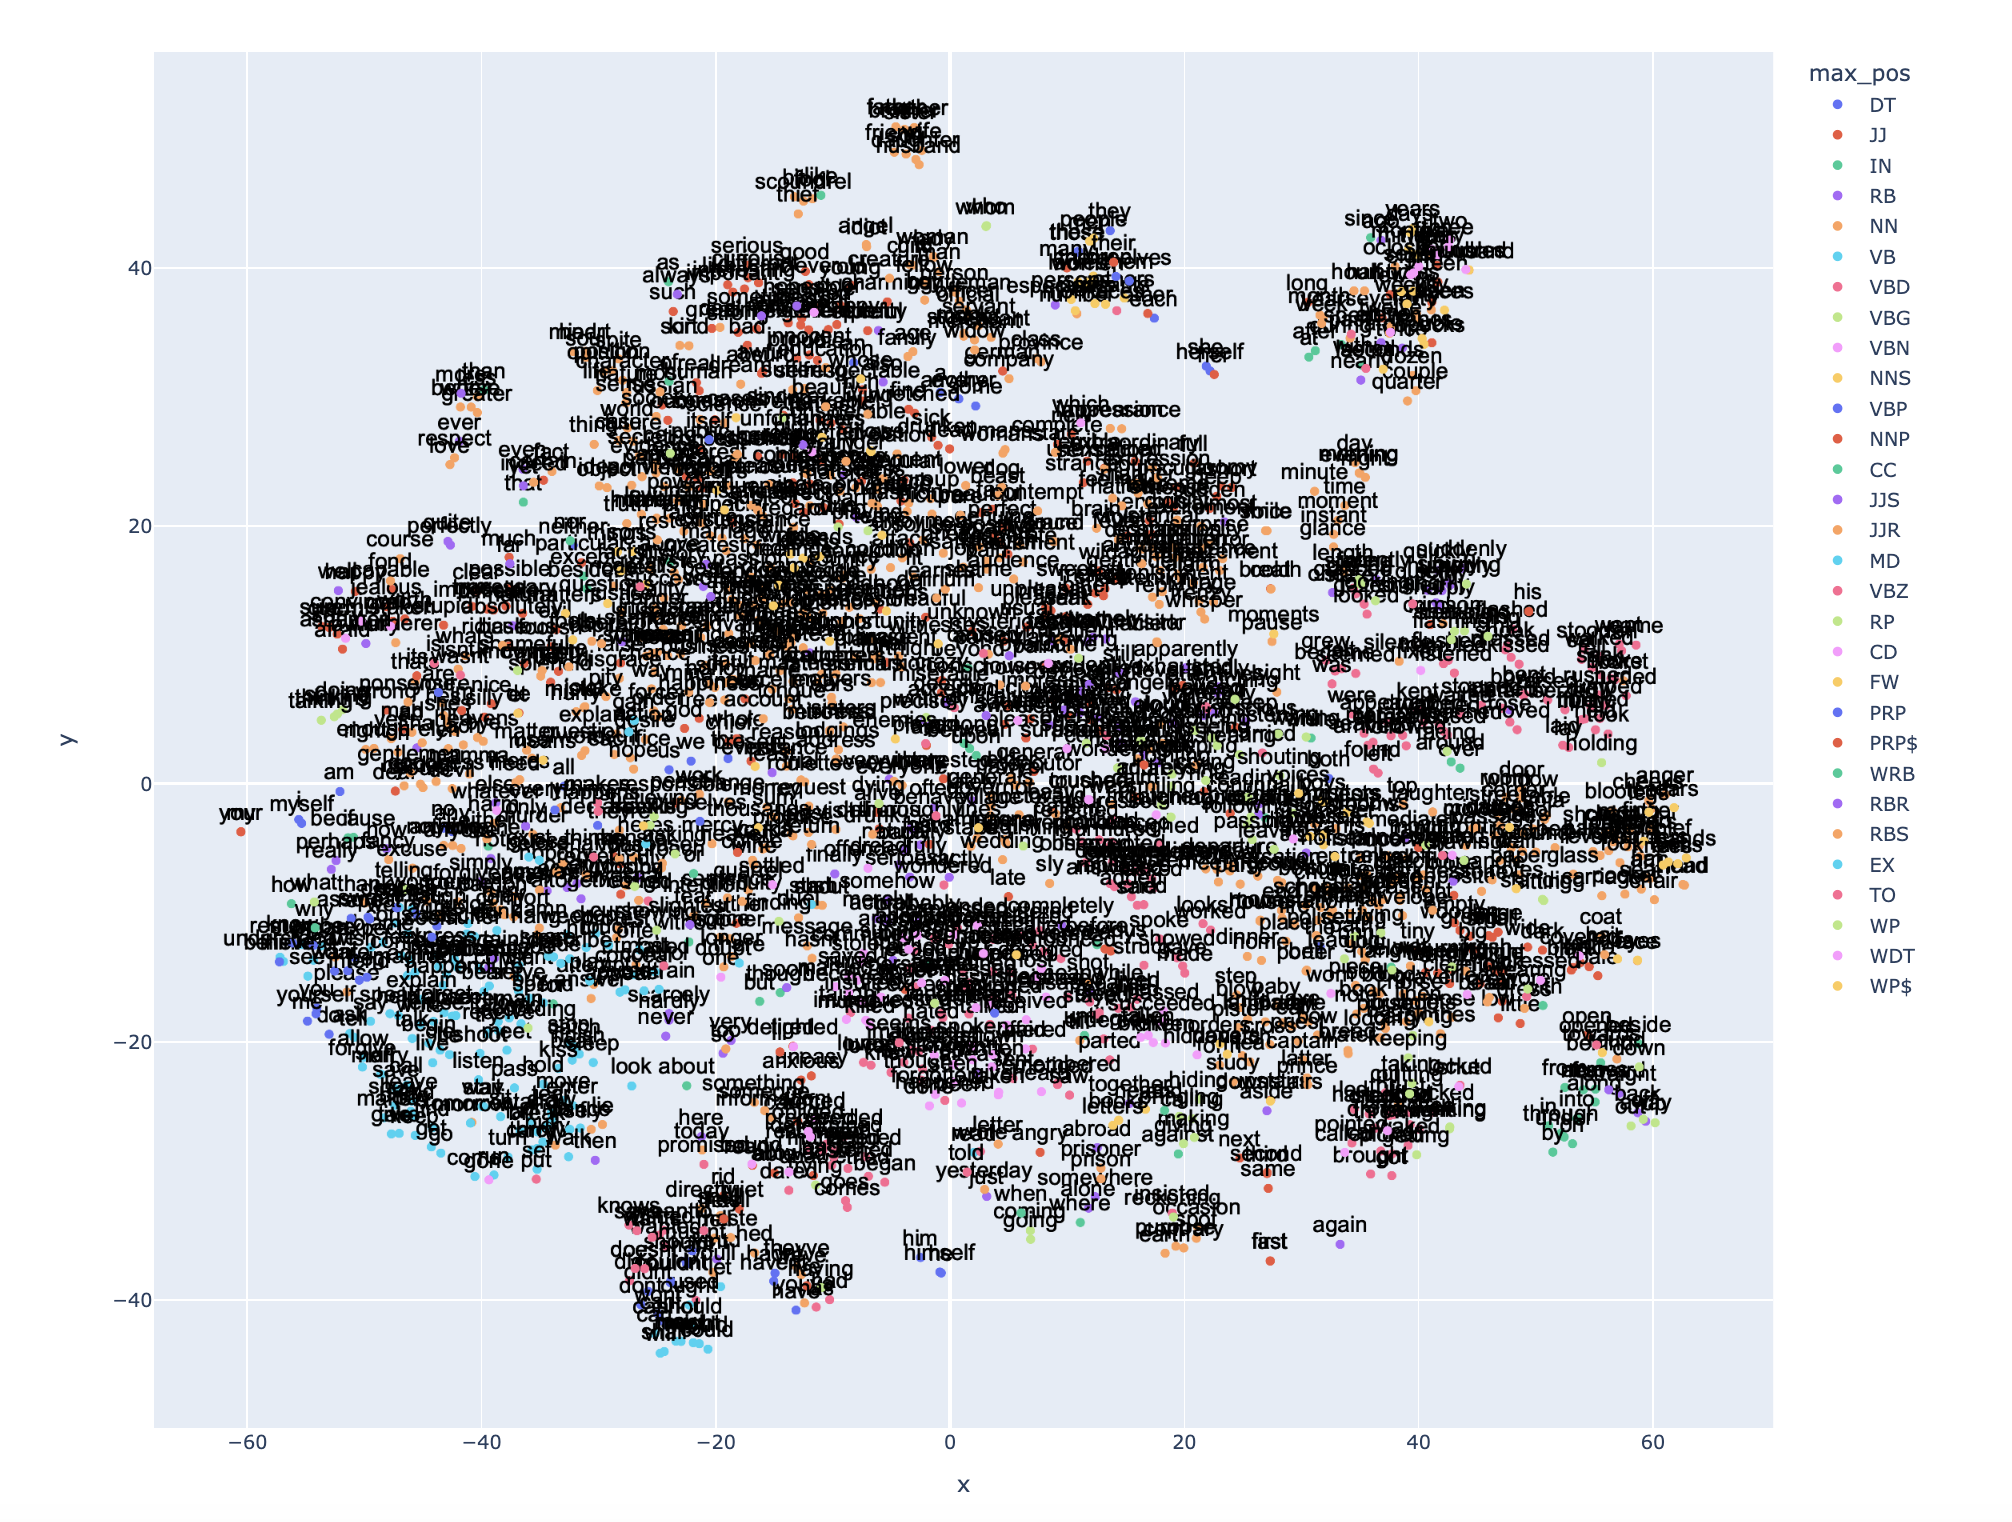

In [11]:
Image(filename='tSNE_plot.png')

**One noteworthy cluster is the one located around (60, -5). It is hard to make out in the image, but this cluster is made up of words such as anger, tears, hands, head, handkercheif, mouth, seat, chair, revolver, blood, and more. While some of these words don't seem directly related, to me they conjur up a very Dostoevsky-esque image. 'Blood' and 'revolver' indicate a murder, or at least a struggle and fight that comes with high stress and anger. 'Seat', 'chair', 'head', 'hands', 'anger', and 'tears' summon the image of a man who has just killed and is sitting in anger and despair at what has just happened. Dostoevksy does not shy away from the true emotional impact of dark subjects- in *Crime and Punishment* for example, most of the story is about the main character's descent into guilt and paranoia after committing a murder. The image generated by this word cluster reminds me of a scene from that book.**

# Riffs

Provde at least three visualizations that combine the preceding model data in interesting ways.

These should provide insight into how features in the LIB table are related. 

The nature of this relationship is left open to you -- it may be correlation, or mutual information, or something less well defined. 

In doing so, consider the following visualization types:

- Hierarchical cluster diagrams
- Heatmaps
- Scatter plots
- KDE plots
- Dispersion plots
- t-SNE plots
- etc.

## Riff 1 (5)

### Exploring topic weight for each translator

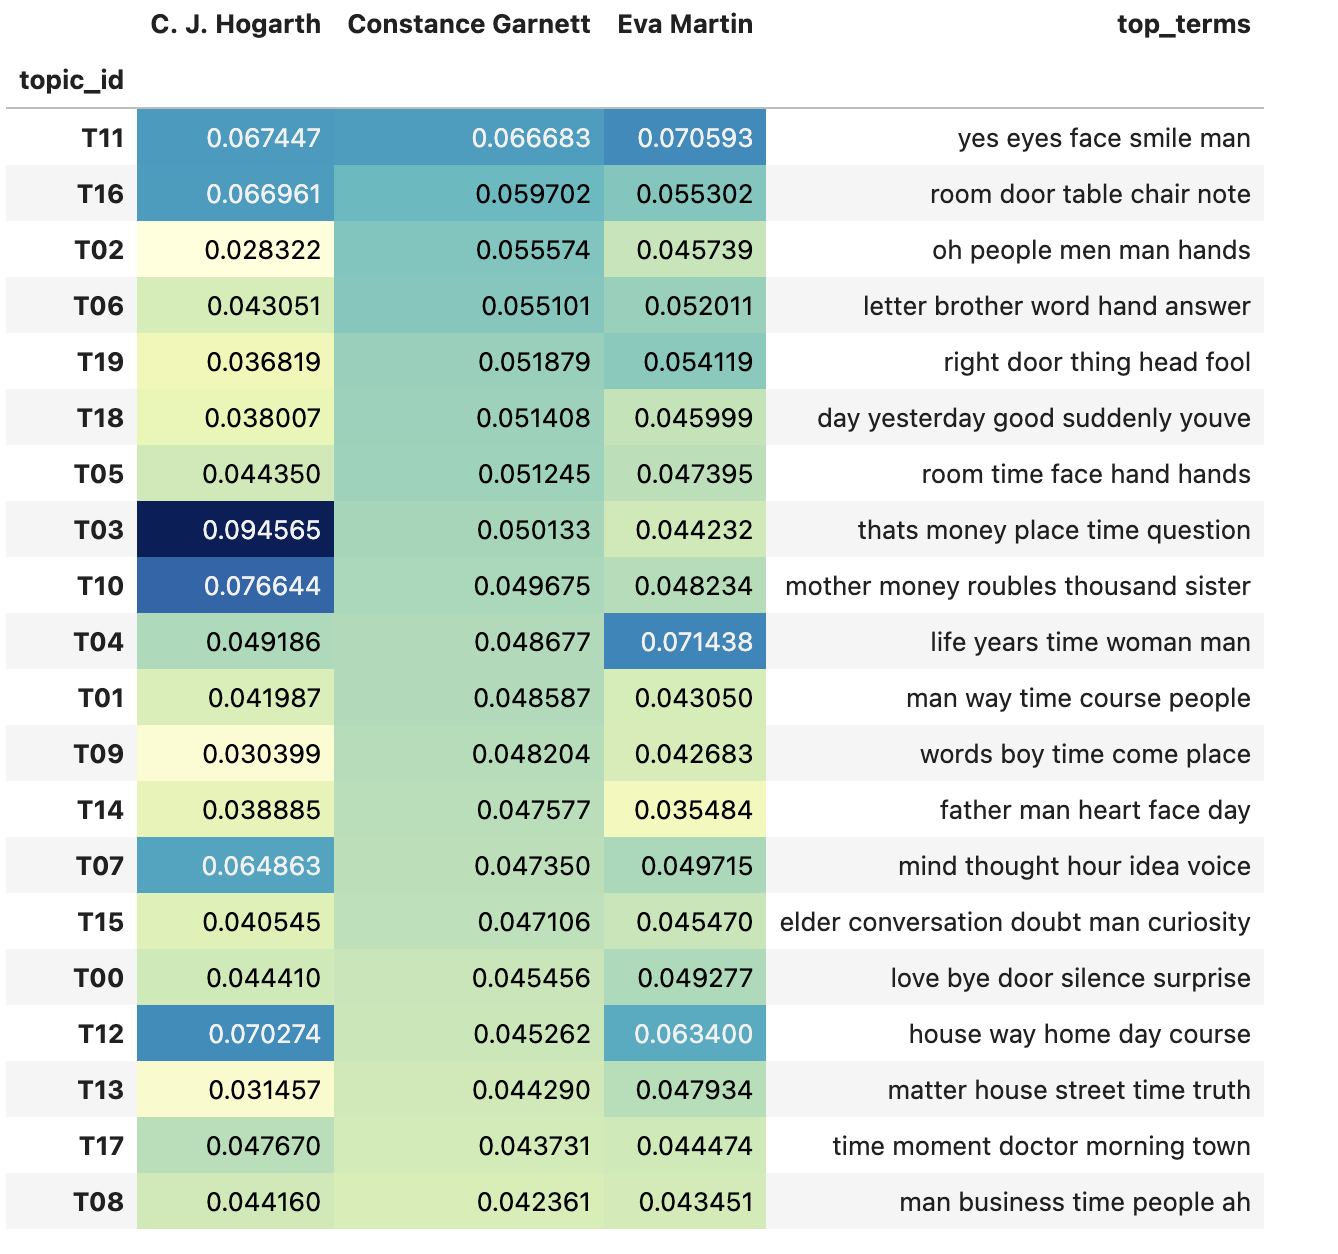

In [14]:
Image(filename='Riff1.png')

**This table shows topic weights organized by the translator who worked on the book. It is interesting to see that there are some differences, for example C. J. Hogarth translated *The Gambler,* a book centered around gambling (as the title implies). The two topics that are most defined by money, topics 3 and 10, are by far the two most strongly associated with this work. In fact, they are the two most strongly associated with any translator's body of work.** 

**Another insight we can gain from this table is the Constance Garnett (who is responsible for four out of six works in this corpus) has a relatively even distribution of topics associated with her works. With the highest being 0.067 and the lowest being 0.042, she has the smallest range of any translator.**

**Topic 12 jumps out as one that is weakly associated with Garnett, but strongly associated with Hogarth and Martin. This could suggest that Garnett's style of translation places less emphasisis on these kinds of ideas and more on other aspects of the story she is translating. Topic 12 includes words such as "house" "home" and "lady", which are all words associated with home (most of Dostoevsky's work centered around men, which is why "lady" could be associated more with the home in this corpus). Perhaps Garnett's style was more focused on the events outside the home and paid less attention to the mundane, but realistic, parts of life. It is also possible that she translated books that simply happened to not place emphasis on this topic, but the difference is interesting nonetheless.**

## Riff 2 (5)

### Exploring Sentiment for each translator

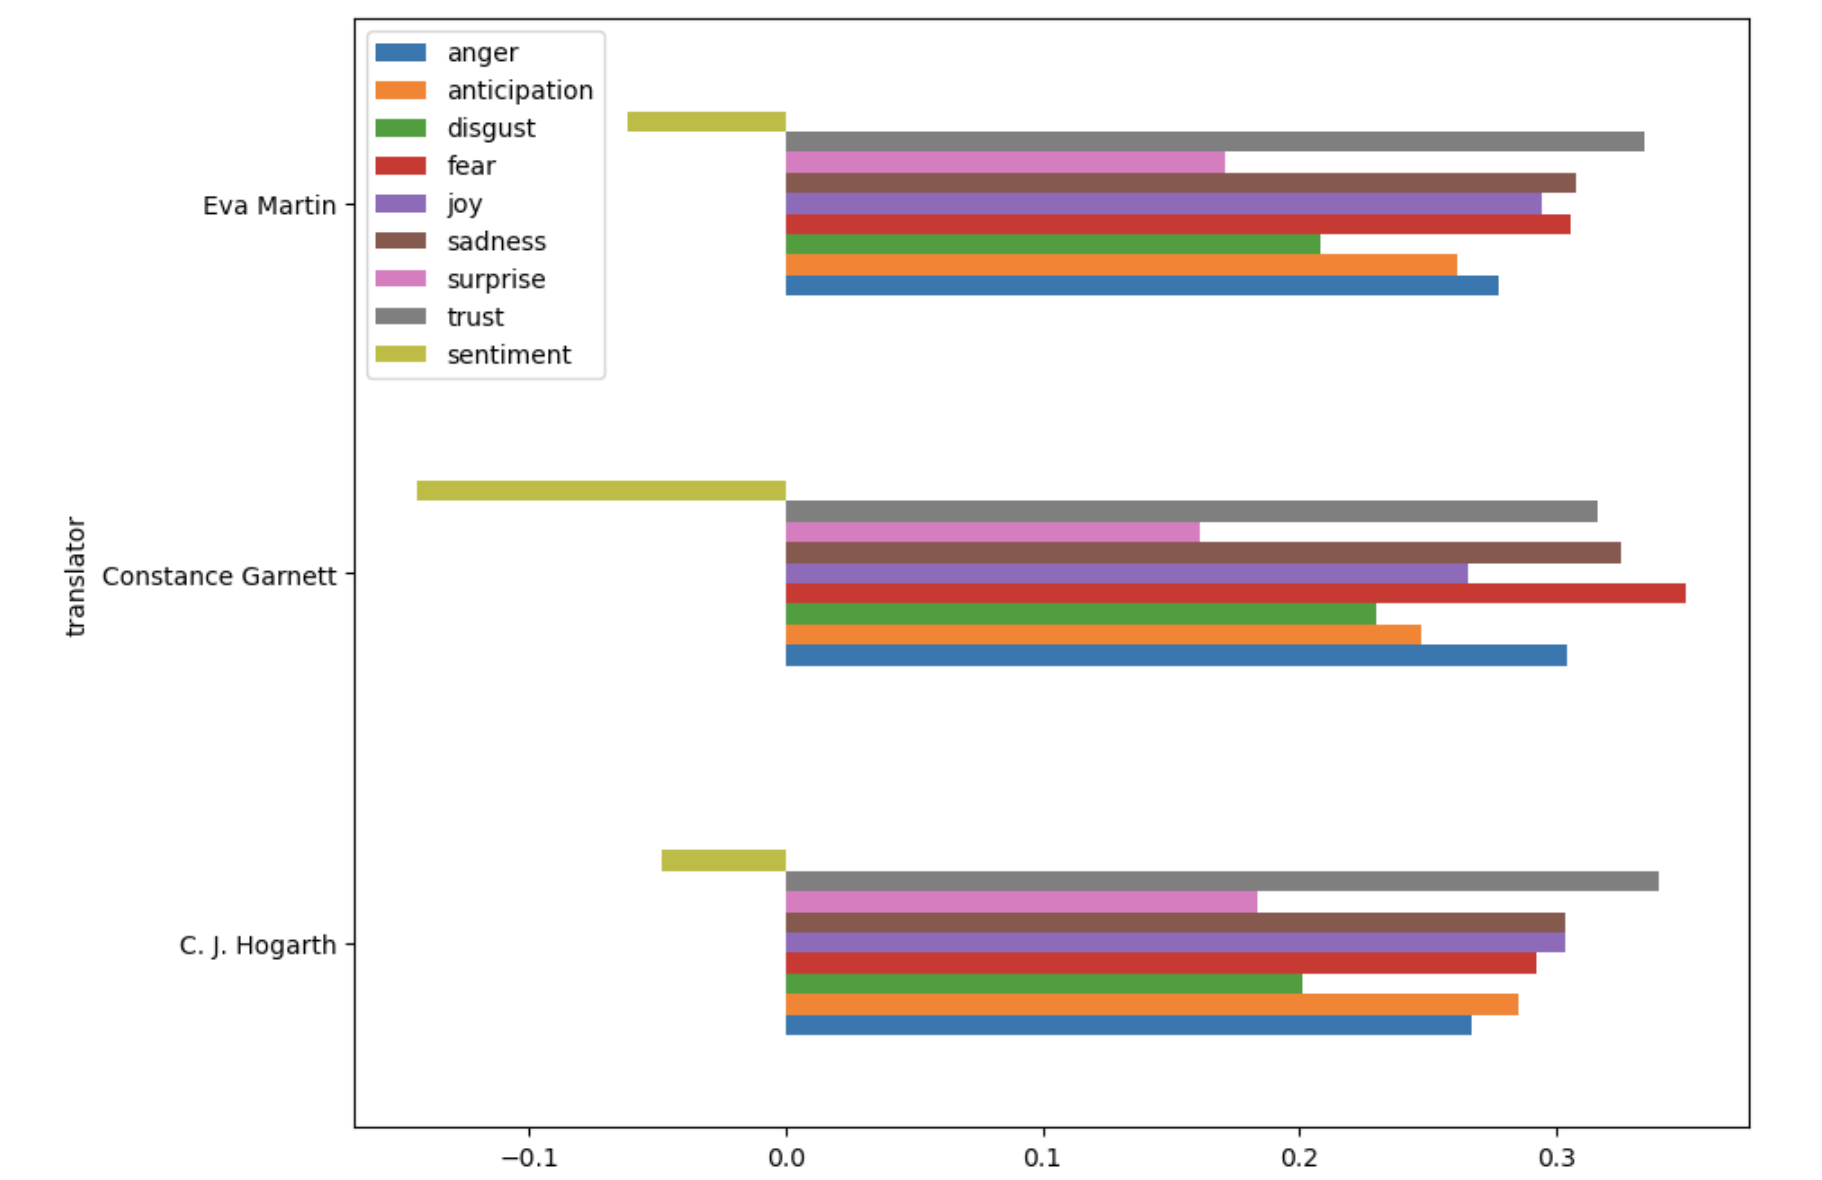

In [15]:
Image(filename='Riff2.png')

**This plot shows an analysis of sentiment for each translator's work. It is interesting that Garnett's work tends to have a lower sentiment score, even though much of Dosoevsky's work is rather dark- not just the works translated by Garnett. For example, C. J. Hogarth translated *The Gambler,* which deals with themes of addiction and obsession, called "dark and compelling" by Random House Canada. This suggests that that translators may, and likely do, play an influential role in the reader's interpretation of the novel. The Sentiment Plot by date from earlier in the project shows that Dostoevsky stays relatively constant in terms of sentiment throughout this portion of his career, so some of the differences shown in this plot could very well be due to translators' choices.**

**Garnett has higher scores in fear, anger, and sadness than the other two translators, and a lower score in joy and trust.** 

**Regardless of the specifics, this plot and the table from Riff 1 show that a translator's choices likely do make a difference on the document. There can not be any one "correct" way to translate a novel, especially one written by as talented an author as Dostoevsky. Each translator must have some form of their own voice and style, and make the best choices that they can when translating. The end result is something that is slightly different from the original, but beautiful and artistic in its own way. This table shows an example of this difference.**

## Riff 3 (5)

### Looking for changes in Dostoevsky's work over time

**In this Riff, we will look at chapters in component space from the PCA work we did earlier in the project, as well as sentiment change by date. This Riff contains three visualizations.**

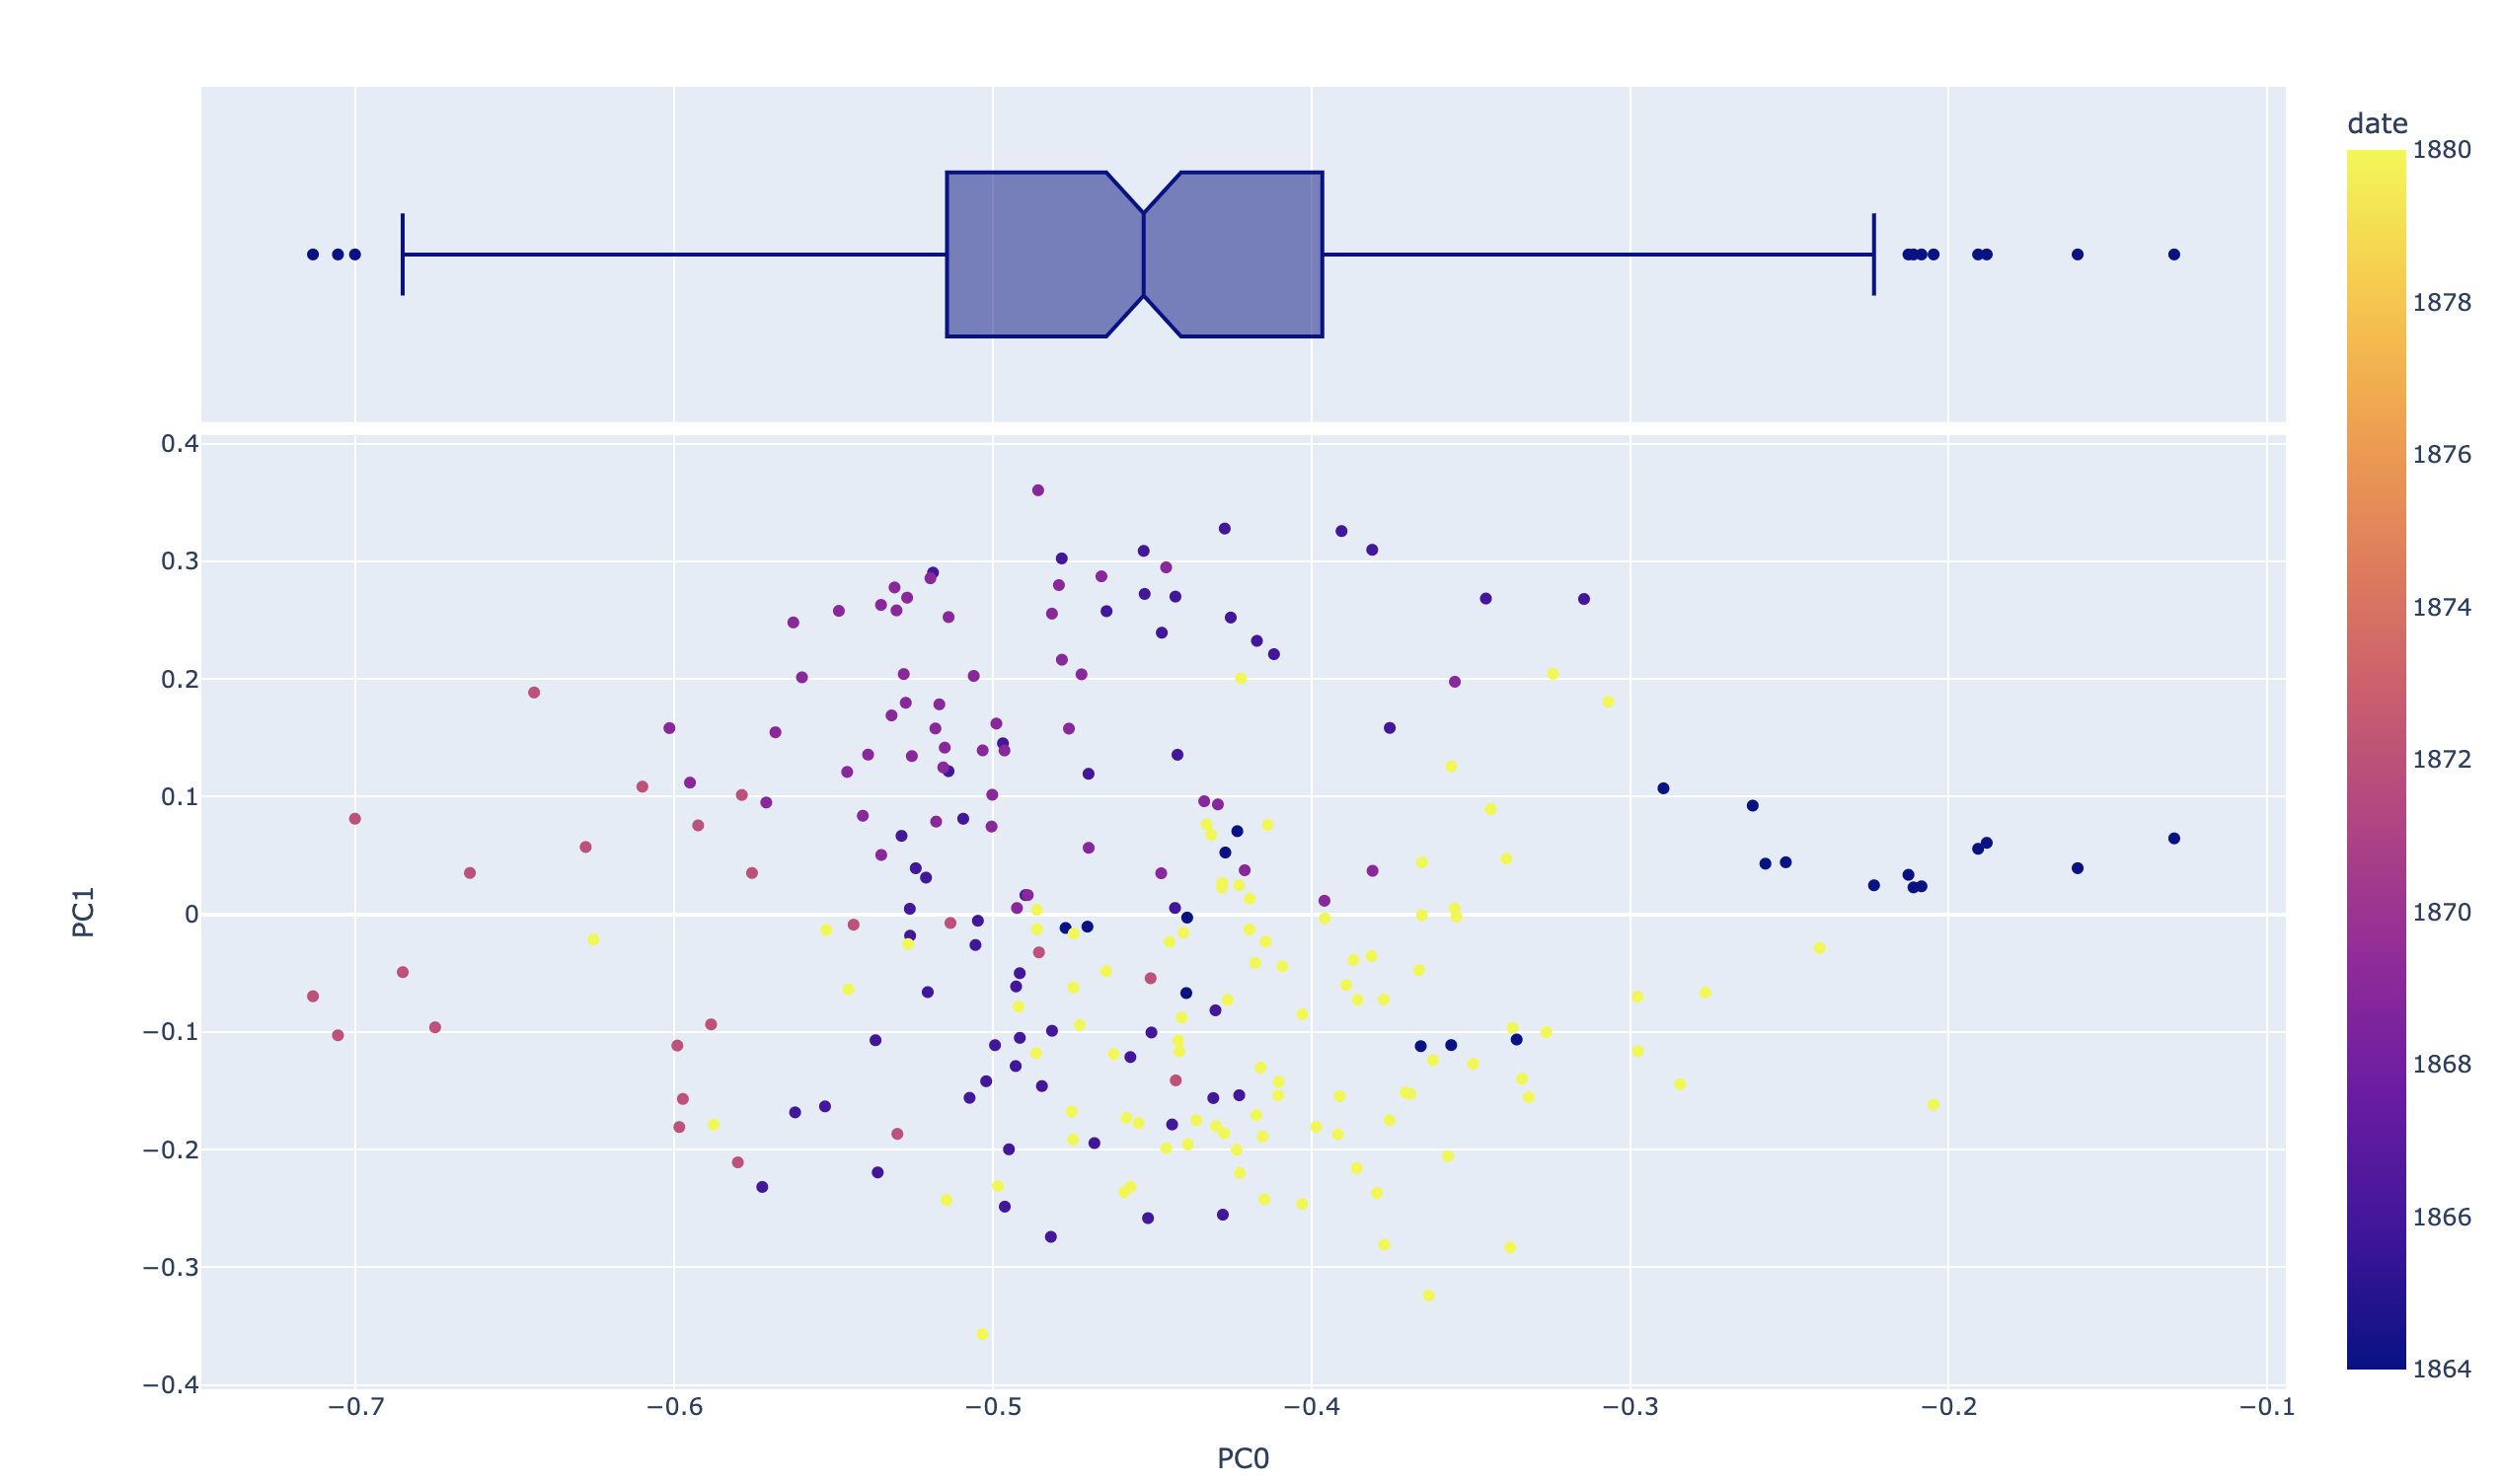

In [16]:
Image(filename='Riff3_1.png')

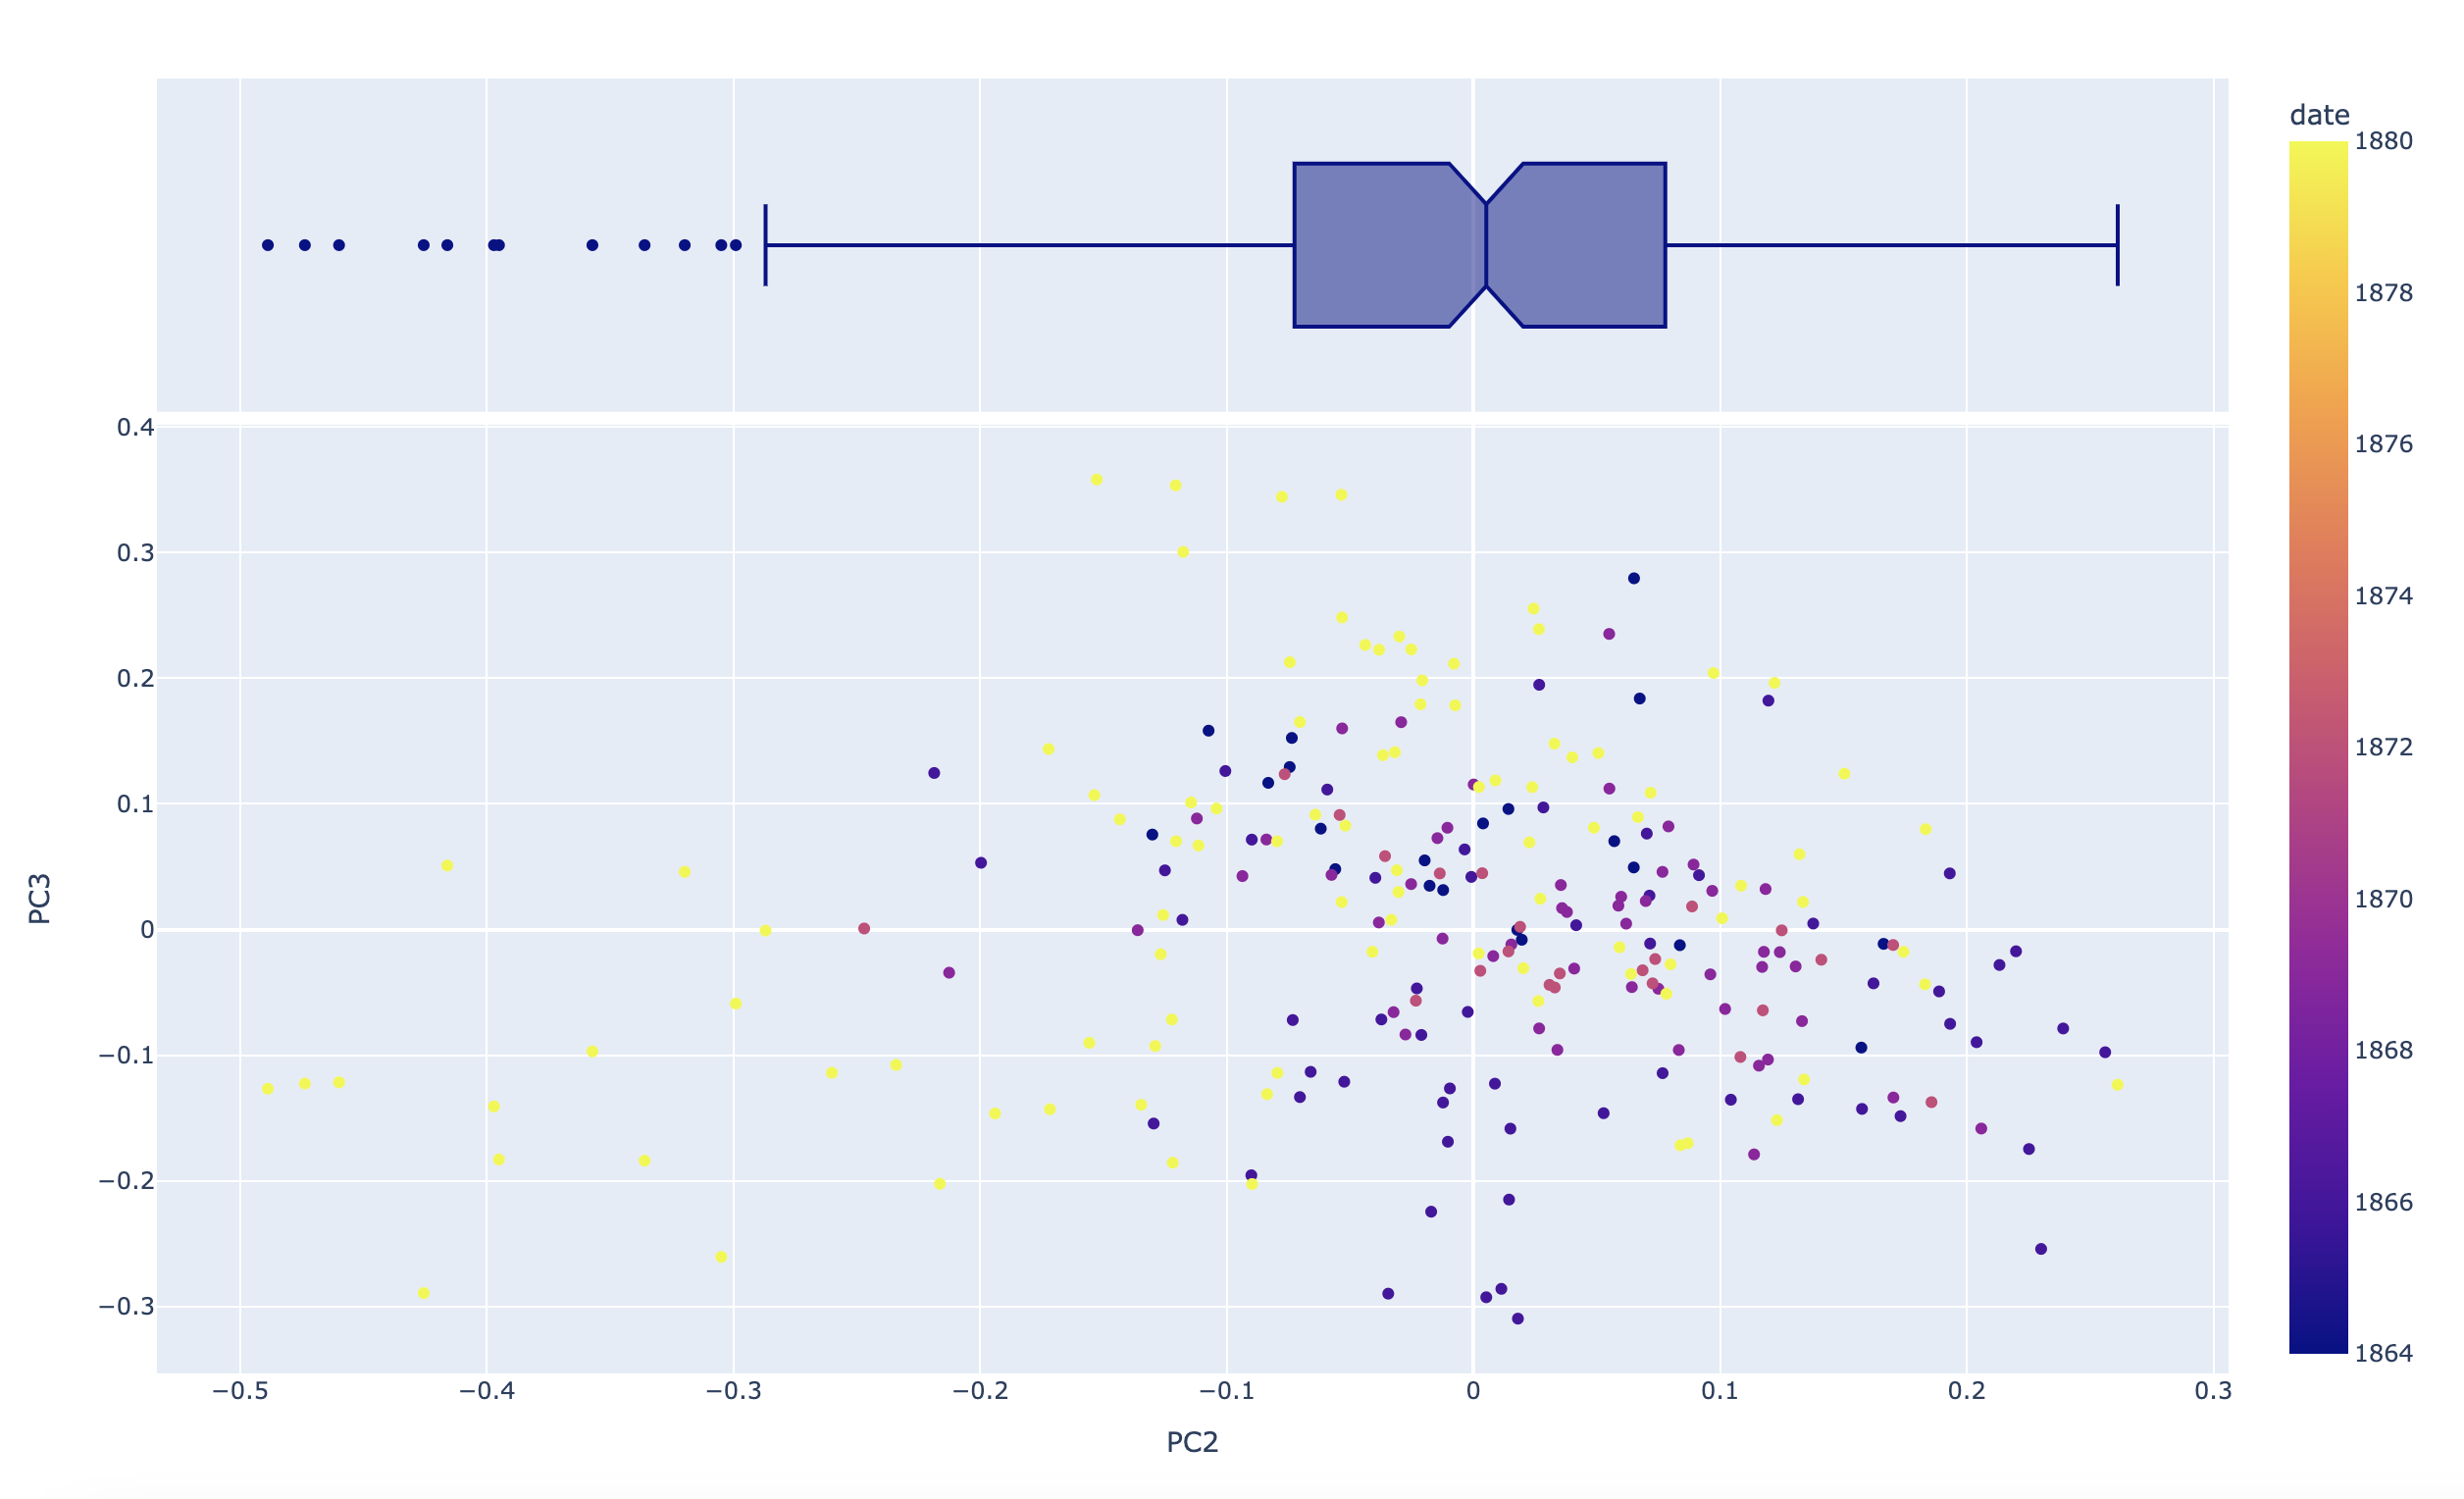

In [17]:
Image(filename='Riff3_2.png')

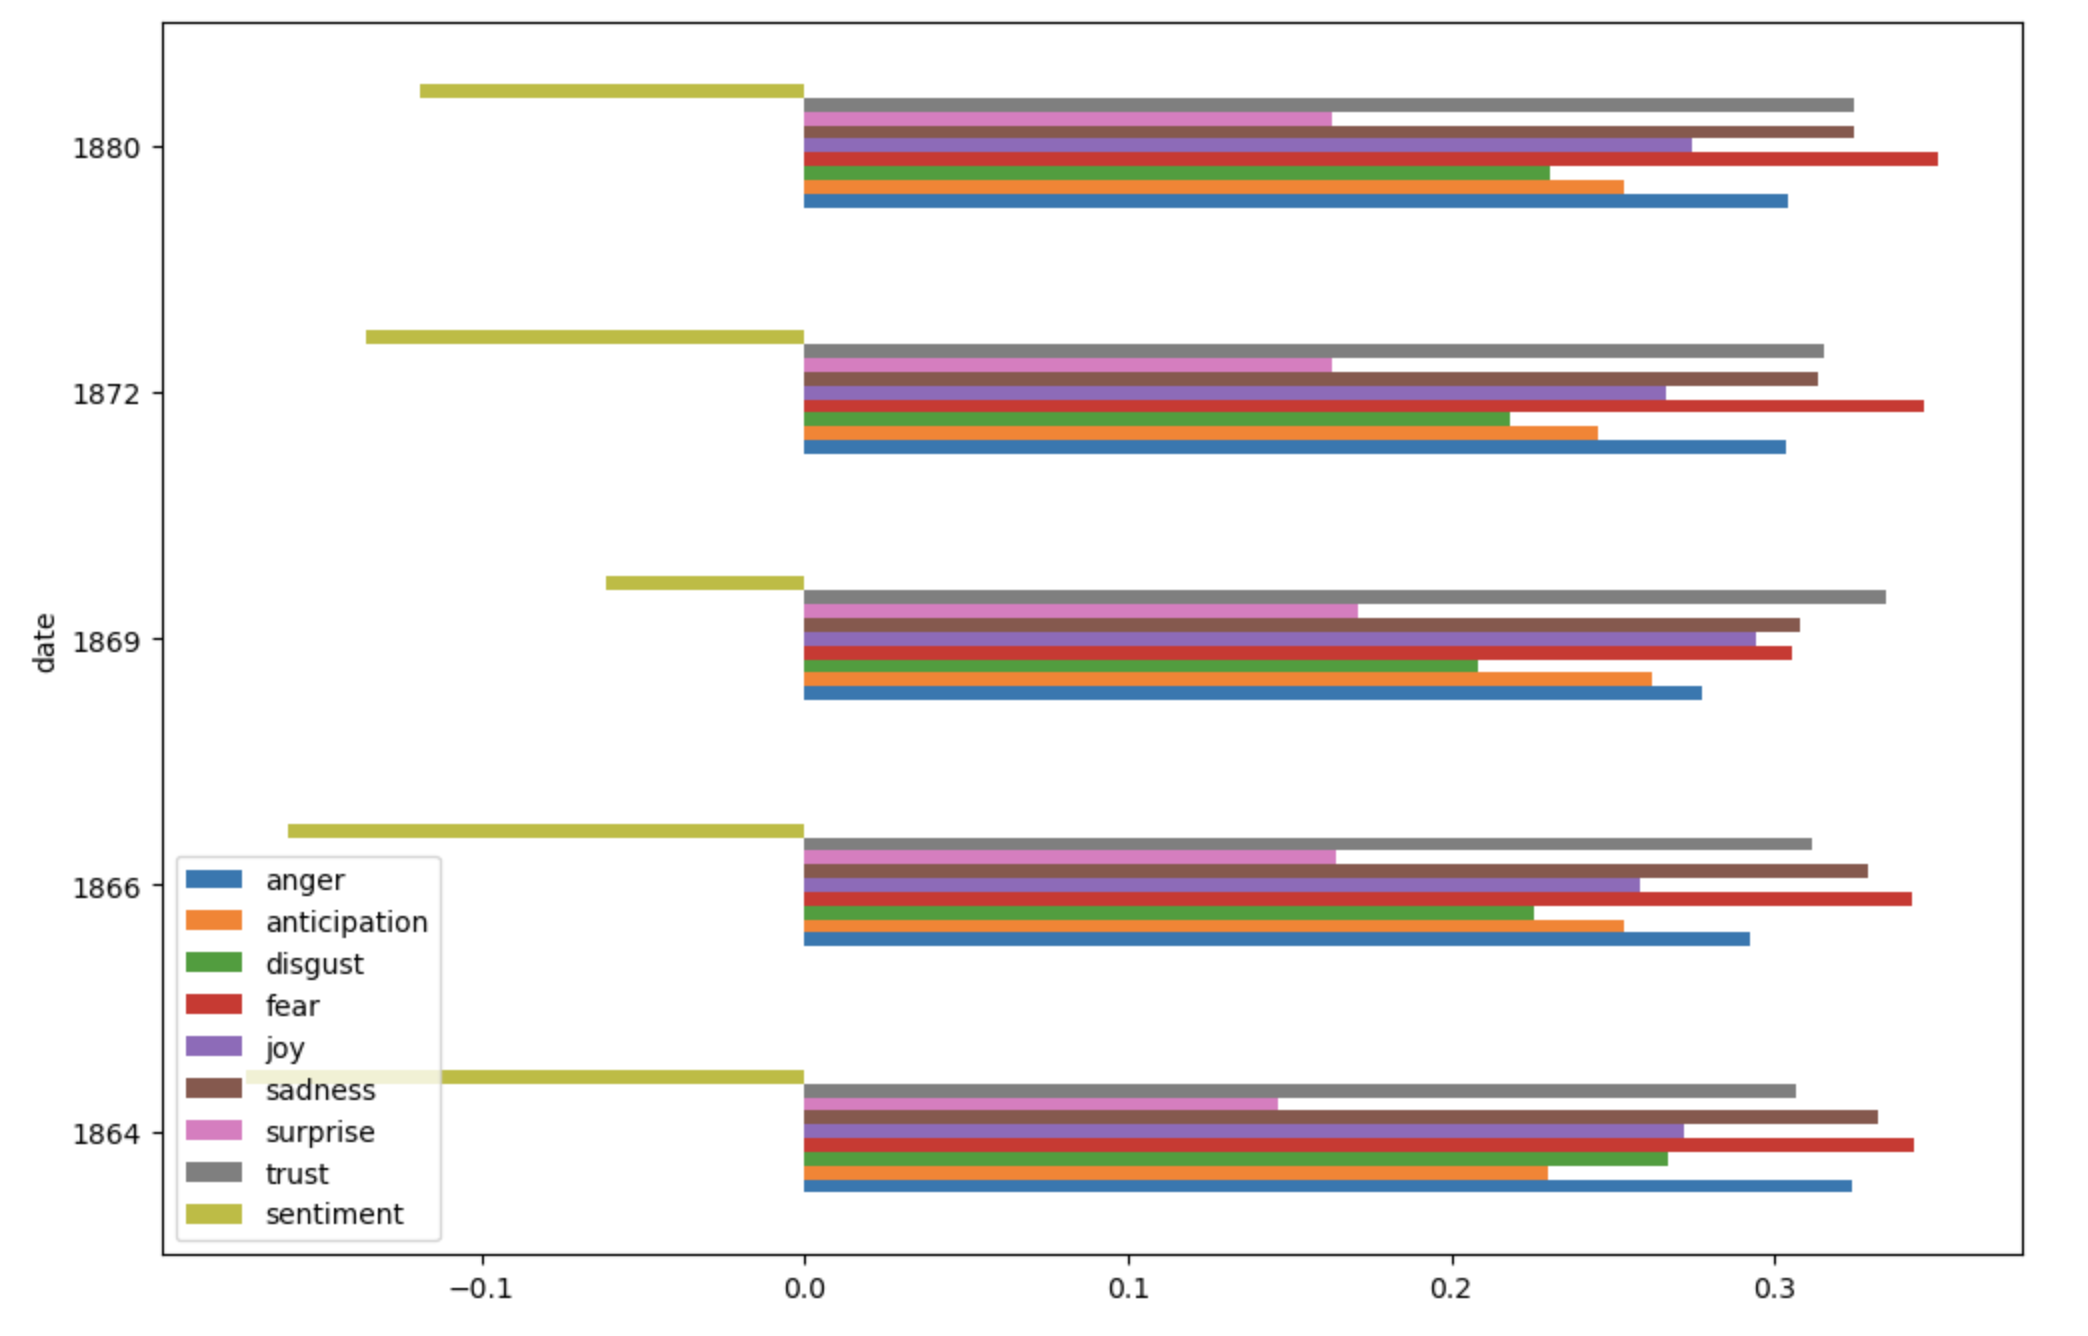

In [18]:
Image(filename='Riff3_3.png')

**The PCA plots above show very little distinction based on date, and certainly no clearly defined trend. The sentiment plot shows some difference by date, and a rather weak trend over time. However, sonsidering that he never released more than one book per year in this stretch of his career, we cannot say that the differences are based on time, rather they are likely simply based on the subject of whatever work he released that year. The works released in 1864 and 1866 are notably the ones with the most negative sentiment, however the general graphs for each year are similar in terms of which emotions are high and which are low.**

**These results show that, while many authors such as Jane Austen change over time, Dostoevsky stays relatively consistent throughout this portion of his career in terms of the components of his work and the sentiment behind it. This makes some sense because when writing these works, Dostoevsky is much older than Jane Austen was when she began writing so he is less likely to change in his real life. Also, much of his work is inspired by the suffering and hardship he endured when he was younger. These plots suggest that those themes remain relatively constant in his work since the major emotions in his books stay the same.**

**Capturing these results also gives more context to the previous Riffs that explored differences between translators. We can see that Dostoevsky is consistent in his works over long stretches of time, so it becomes more plausible that differences in sentiment comes down to other factors- such as translation.**

## Riff 4 (Extra- this one is not focused on a LIB feature but I just found it interesting)

### This is a sentiment plot by chapters for *Crime and Punishment*

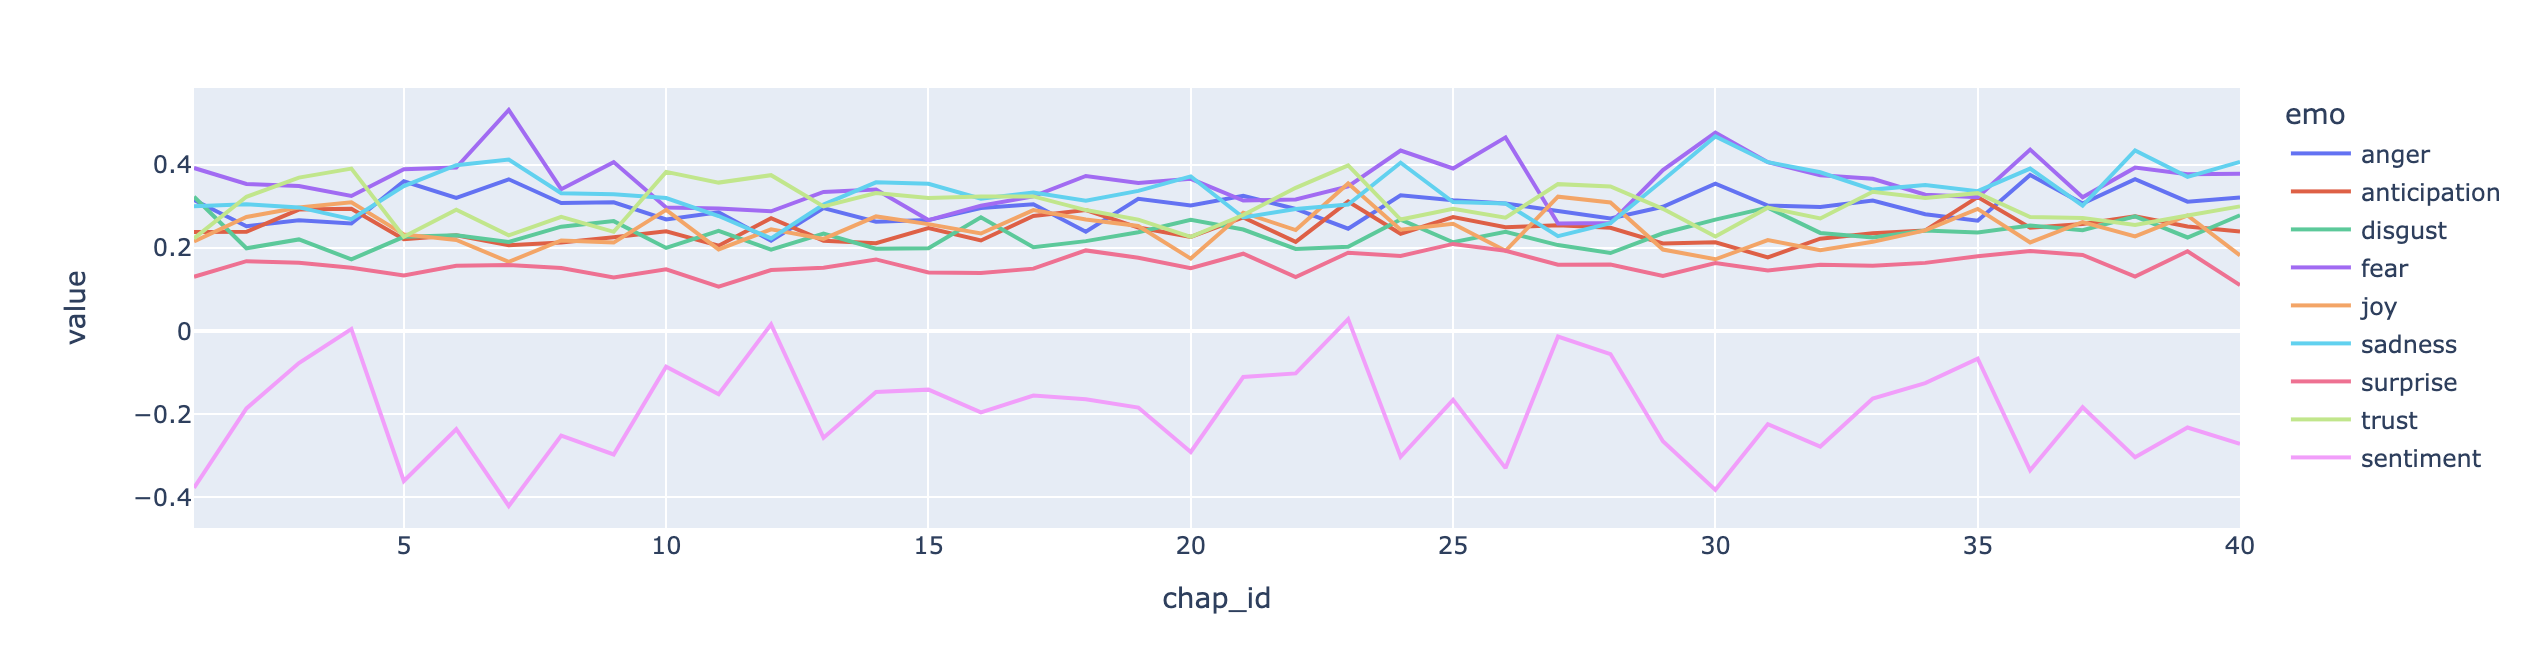

In [19]:
Image(filename='Riff4.png')

**In this plot, is interesting to note that 'fear' is nearly always the most prominent emotion. It is also interesting to consider what is happening in the novel when we see the 3 biggest spikes in fear. In chapter 7, Rodion kills the two women and is almost caught right away. In chapter 26, he is almost caught again but saved by an unexpected distraction. In chapter 30, he confesses to the murders in front of a character who is a trusted friend, and we see fear and sadness spike while trust dips.**

***Crime and Punishment* is my favorite work by Dostoevsky, particularly for it's major theme that the *punishment* to a severe *crime* can often be the feelings that the criminal endures- the fear, guilt, and remorse. The pattern we see in this sentiment plot supports the idea that the true punishment is the fear and paranoia that Rodion lives in after his crime. His mental state deteriorates dramatically, even as he evades legal punishment for his crime, and the atmosphere of the book mirrors these emotions closely. Dostoevsky is very good at making the reader feel what his characters are feeling, and this plot is able to visualize that phenomenon.**

# Interpretation (4)

Describe something interesting about your corpus that you discovered during the process of completing this assignment.

At a minumum, use 250 words, but you may use more. You may also add images if you'd like.

**My main takeaway from this assignment is that translators can, and often do, make a measurable difference in experience of reading a text in a different language**

**Both PCA and sentiment analysis revealed a difference between works depending on who translated them from the original Russian into English. Constance Garnett, a well-known translator of Russian literature, tended to have the most negative sentiment attached to her translations. This is not a bad thing, by any means, as we also discovered that Dostoevsky's work is typically dark. Therefore, a Garnett's translations may be the most faithful to the source material.**

**As art crosses cultural barriers, translation will always play a part in how certain peoples' experiences differ from others. This project revealed that translation is essentially its own form of art and goes beyond simply writing words in a different language. Context, sentence structure, or idioms that only exist in one language may force the translation to stray from a 1-to-1 replica and become something new.**

**It would be fascinating to conduct this same project on the original Russian texts and and see the results. Many of the differences between translators that were revealed in this project could also be due to the book that is being translated. For example, C.J. Hogarth had the highest overall sentiment score, but the only work in this corpus that he translated was *The Gambler.* Does *The Gambler* simply have a higher sentiment score than the rest of Dostoevsky's works? Running this same project on the original Russian texts could help answer that question. It would also be interesting to compare the collective understanding of these texts from Russian speakers' points of view to English speakers' points of view.**